# Results Plotting Notebook

This notebook consumes `results.pt` produced by `collect_results.py` and generates Figures 1 through 8.

Expected top-level keys:

```python
{
    "motivation": [...],
    "insight": [...],
    "trace": [...],
    "results": [...],
}
```


In [242]:
import os
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

sns.set_palette("tab10")
sns.set_style("whitegrid")
plt.rc("font", size=12)

# =========================
# User parameters
# =========================
RESULTS_PT = Path("./results.pt")
PLOTS_DIR = Path("./plots_results")
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

BATCH_SIZE = 16
SPECULATIVE_LENGTH = 5
HIERARCHICAL_ROUND = 1

# Figures 1-5 use the same batch size / speculative length configuration.
TRACE_SPECULATIVE_LENGTH = SPECULATIVE_LENGTH
TOPK_SPECULATIVE_LENGTH = SPECULATIVE_LENGTH
CONF_SPECULATIVE_LENGTH = SPECULATIVE_LENGTH

# Figure 5 explicitly requires k=3 and k=7 in the old script; kept for Figure 6+ compatibility.
# INTRA_BATCH_SPECULATIVE_LENGTHS = [3, 7]
INTRA_BATCH_SPECULATIVE_LENGTHS = [5]
# Optional filters. Set to None to include everything.
METHOD_FILTER = None
DATASET_FILTER = [
    "Alpaca",
    "NaturalQA",
    "CodeELO",
    "Math500",
]
TARGET_MODEL_FILTER = None
MODEL_PAIR_FILTER = None

# Pretty names for common methods.
METHOD_RENAME = {
    "ar": "AR",
    "autoregressive": "AR",
    "auto_regressive": "AR",
    "sync": "SD",
    "speculative_decoding": "SD",
    "speculative": "SD",
    "draft_model": "SD",
    "hierarchical": "HV",
    "hierarchical_verification": "HV",
    "hispec": "HV",
    "spechive": "HV",
    "eagle3": "Eagle3",
    "eagle": "Eagle3",
    "pivot": "Pivot",
    "pivot_hierarchical": "Pivot + HV",
}

DATASET_RENAME = {
    "alpaca": "Alpaca",
    "qa": "NaturalQA",
    "codeelo": "CodeELO",
    # "gsm8k": "GSM8K",
    "math500": "Math500",
}

TEMPERATURES = [0.0, 0.3, 0.7]
TEMP_COL_CANDIDATES = ["temperature", "temp", "sampling_temperature", "sampling_temp"]

METHOD_ORDER = ["AR", "SD", "HV", "Eagle3", "Pivot", "Pivot + HV"]
# DATASET_ORDER = ["Alpaca", "CodeELO", "GSM8K", "Math500"]
DATASET_ORDER = ["Alpaca", "NaturalQA", "CodeELO", "Math500"]
FIGURE_1_METHODS = ["AR", "SD", "Eagle3"]
FIGURE_2_4_METHODS = ["SD", "Eagle3"]
FIGURE_5_METHODS = ["SD", "SD-Oracle"]

# Match the attached notebook style.
FIGSIZE_WIDE = (8, 2)
FIGSIZE_TALL = (8, 2)
FIGSIZE_GRID = (8, 2.4)
DPI = 600


In [243]:
# =========================
# Load and normalize data
# =========================

data = torch.load(RESULTS_PT, map_location="cpu")

motivation_df = pd.DataFrame(data.get("motivation", []))
insight_df = pd.DataFrame(data.get("insight", []))
trace_df = pd.DataFrame(data.get("trace", []))
results_df = pd.DataFrame(data.get("results", []))

def normalize_common_columns(df):
    if df.empty:
        return df.copy()

    out = df.copy()

    if "speculate_k" in out.columns and "speculative_length" not in out.columns:
        out = out.rename(columns={"speculate_k": "speculative_length"})

    if "method" in out.columns:
        out["method_pretty"] = out["method"].map(METHOD_RENAME).fillna(out["method"])

    if "dataset" in out.columns:
        out["dataset"] = out["dataset"].astype(str).map(lambda x: DATASET_RENAME.get(x.lower(), x))

    if "target_model" in out.columns and "draft_model" in out.columns:
        out["model_pair"] = out["target_model"].astype(str) + "+" + out["draft_model"].astype(str)
    else:
        out["model_pair"] = "unknown"

    if "target_model" not in out.columns:
        out["target_model"] = out["model_pair"].astype(str).str.split("+").str[0]

    if "batch_size" in out.columns:
        out = out[out["batch_size"] == BATCH_SIZE]

    # Hierarchical runs are stored under .../t0/r{round}/dataset.
    # Keep the selected round while leaving non-hierarchical rows untouched.
    if "round" in out.columns and "method_pretty" in out.columns:
        out = out[(out["method_pretty"] != "HV") | (out["round"].fillna(HIERARCHICAL_ROUND) == HIERARCHICAL_ROUND)]

    if METHOD_FILTER is not None and "method" in out.columns:
        out = out[out["method"].isin(METHOD_FILTER)]

    if DATASET_FILTER is not None and "dataset" in out.columns:
        out = out[out["dataset"].isin(DATASET_FILTER)]

    if TARGET_MODEL_FILTER is not None and "target_model" in out.columns:
        out = out[out["target_model"].isin(TARGET_MODEL_FILTER)]

    if MODEL_PAIR_FILTER is not None and "model_pair" in out.columns:
        out = out[out["model_pair"].isin(MODEL_PAIR_FILTER)]

    return out

motivation_df = normalize_common_columns(motivation_df)
insight_df = normalize_common_columns(insight_df)
trace_df = normalize_common_columns(trace_df)
results_df = normalize_common_columns(results_df)

def method_sort_key(method):
    if method in METHOD_ORDER:
        return METHOD_ORDER.index(method)
    return len(METHOD_ORDER)

def sorted_methods(methods):
    return sorted(methods, key=method_sort_key)

def dataset_sort_key(dataset):
    dataset = str(dataset)
    if dataset in DATASET_ORDER:
        return (0, DATASET_ORDER.index(dataset))
    return (1, dataset)

def sorted_datasets(datasets):
    return sorted([d for d in datasets if pd.notna(d)], key=dataset_sort_key)

def sorted_model_pairs(*dfs):
    pairs = set()
    for df in dfs:
        if not df.empty and "model_pair" in df.columns:
            pairs.update(df["model_pair"].dropna().unique().tolist())
    return sorted(pairs)

def sorted_target_models(*dfs):
    targets = set()
    for df in dfs:
        if not df.empty and "target_model" in df.columns:
            targets.update(df["target_model"].dropna().astype(str).unique().tolist())
    return sorted(targets)

model_pairs = sorted_model_pairs(motivation_df, insight_df, trace_df, results_df)
target_models = sorted_target_models(motivation_df, insight_df, trace_df, results_df)
temp_col = get_temp_col(motivation_df)

print("Loaded:")
print(f"  motivation rows: {len(motivation_df)}")
print(f"  insight rows:    {len(insight_df)}")
print(f"  trace rows:      {len(trace_df)}")
print(f"  results rows:    {len(results_df)}")
print(f"  target models:   {len(target_models)}")
print(f"  model pairs:     {len(model_pairs)}")
display(pd.DataFrame({"target_model": target_models}))


Loaded:
  motivation rows: 114
  insight rows:    114
  trace rows:      114
  results rows:    132
  target models:   2
  model pairs:     4


,target_model
0,Llama-3.3-70B-Instruct
1,Qwen3-32B


In [233]:
# =========================
# Plot helpers
# =========================

palette = sns.color_palette("tab10")

FIXED_COLORS = {
    "Target Verification": palette[0],
    "Intermediate Verification": palette[1],
    "Draft": palette[2],
    "Others": palette[3],
    "AR": palette[0],
    "SD": palette[1],
    "HV": palette[2],
    "Eagle3": palette[3],
    "SD-Oracle": palette[4],
    "HV-Oracle": palette[5],
}

def color_map(labels):
    return {label: FIXED_COLORS.get(label, palette[i % len(palette)]) for i, label in enumerate(labels)}

def safe_name(name):
    return (
        str(name)
        .replace("/", "__")
        .replace("+", "__PLUS__")
        .replace(" ", "_")
        .replace(":", "_")
    )

def save_fig(fig, out_dir, basename):
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    pdf_path = out_dir / f"{basename}.pdf"
    png_path = out_dir / f"{basename}.png"

    fig.savefig(pdf_path, bbox_inches="tight", dpi=DPI)
    fig.savefig(png_path, bbox_inches="tight", dpi=DPI)
    print(f"saved: {pdf_path}")
    print(f"saved: {png_path}")

def style_axis(ax, xlabel=None, ylabel=None, grid_axis="y"):
    if xlabel is not None:
        ax.set_xlabel(xlabel, fontsize=12)
    if ylabel is not None:
        ax.set_ylabel(ylabel, fontsize=12)
    ax.tick_params(axis="both", which="major", labelsize=12)
    ax.grid(True, linestyle=":", axis=grid_axis)

def legend_top(ax, ncol, y=1.25, fontsize=11):
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(
        by_label.values(),
        by_label.keys(),
        loc="upper center",
        bbox_to_anchor=(0.5, y),
        ncol=ncol,
        fancybox=True,
        shadow=False,
        fontsize=fontsize,
        frameon=True,
    )

def get_model_out_dir(model_pair):
    out_dir = PLOTS_DIR / safe_name(model_pair)
    out_dir.mkdir(parents=True, exist_ok=True)
    return out_dir

def get_target_out_dir(target_model):
    out_dir = PLOTS_DIR / safe_name(target_model)
    out_dir.mkdir(parents=True, exist_ok=True)
    return out_dir

def nonempty(df, required_cols, fig_name):
    if df.empty:
        print(f"[skip] {fig_name}: empty dataframe")
        return False
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        print(f"[skip] {fig_name}: missing columns {missing}")
        return False
    return True

def aggregate_mean(df, group_cols, value_col):
    return (
        df.dropna(subset=[value_col])
        .groupby(group_cols, as_index=False)[value_col]
        .mean()
        .sort_values(group_cols)
    )

def first_existing_col(df, candidates):
    for col in candidates:
        if col in df.columns:
            return col
    return None

def require_any_col(df, candidates, fig_name):
    col = first_existing_col(df, candidates)
    if col is None:
        print(f"[skip] {fig_name}: missing any of columns {candidates}")
    return col

def row_number(row, col, default=0.0):
    if col is None:
        return default
    val = row.get(col, default)
    if pd.isna(val):
        return default
    return float(val)

def filter_target_and_k(df, target_model, methods=None, k=SPECULATIVE_LENGTH):
    out = df[df["target_model"].astype(str) == str(target_model)].copy()
    if methods is not None:
        out = out[out["method_pretty"].isin(methods)].copy()
    if "speculative_length" in out.columns:
        # AR uses k=na; keep it explicitly. Non-AR must match k.
        out = out[(out["method_pretty"] == "AR") | (out["speculative_length"] == k)].copy()
    return out

def trace_row_to_series(row):
    values = row.get("target_accept_len_by_request")
    rows = []

    if isinstance(values, dict):
        for request, seq in values.items():
            if not isinstance(seq, (list, tuple, np.ndarray)):
                continue
            for step_id, val in enumerate(seq):
                rows.append({"request": request, "step_id": step_id, "target_accept_len": val})
    elif isinstance(values, (list, tuple, np.ndarray)):
        if len(values) > 0 and isinstance(values[0], (list, tuple, np.ndarray)):
            for request, seq in enumerate(values):
                for step_id, val in enumerate(seq):
                    rows.append({"request": request, "step_id": step_id, "target_accept_len": val})
        else:
            for step_id, val in enumerate(values):
                rows.append({"request": 0, "step_id": step_id, "target_accept_len": val})

    return pd.DataFrame(rows)

def topk_dict_to_row(d):
    if not isinstance(d, dict):
        return {}
    out = {}
    for k in range(2, 6):
        for key in (f"top{k}_prob", f"top_{k}_prob", f"top{k}", f"top_{k}"):
            if key in d:
                out[f"top{k}_prob"] = d[key]
                break
    return out

def geometric_mean(values, eps=1e-12):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    if len(values) == 0:
        return np.nan

    # misspeculation이 0일 수 있으므로 log(0) 방지
    values = np.clip(values, eps, None)
    return float(np.exp(np.mean(np.log(values))))

def get_temp_col(df):
    for col in TEMP_COL_CANDIDATES:
        if col in df.columns:
            return col
    return None

def filter_temperature(df, temp, temp_col=None):
    if temp_col is None:
        return df.copy()

    out = df.copy()
    temp_values = pd.to_numeric(out[temp_col], errors="coerce")
    return out[np.isclose(temp_values, float(temp))].copy()

def safe_temp_label(temp):
    return str(temp).replace(".", "p")

def target_model_family_label(target_model):
    name = str(target_model).lower()
    if "llama" in name:
        return "Llama"
    if "qwen" in name:
        return "Qwen"
    return None

## Figure 1. Normalized Throughput according to the batch size

In [234]:
# Skip for Now


## Figure 2. Normalized TPOT breakdown according to the batch size

In [235]:
# Skip for Now

## Figure 3. Acceptance length traces split by dataset

saved: plots_results/Llama-3.3-70B-Instruct/figure_3_acceptance_length_trace_by_dataset_k5.pdf
saved: plots_results/Llama-3.3-70B-Instruct/figure_3_acceptance_length_trace_by_dataset_k5.png


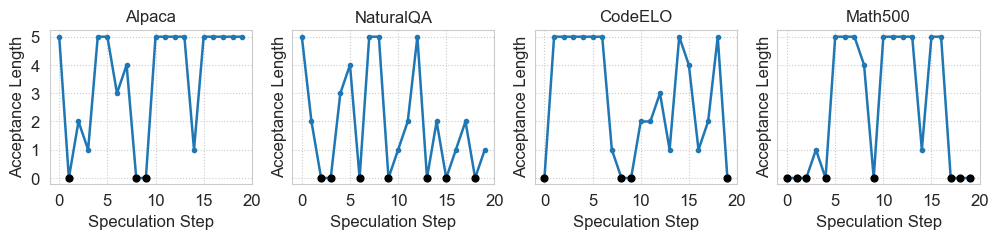

saved: plots_results/Qwen3-32B/figure_3_acceptance_length_trace_by_dataset_k5.pdf
saved: plots_results/Qwen3-32B/figure_3_acceptance_length_trace_by_dataset_k5.png


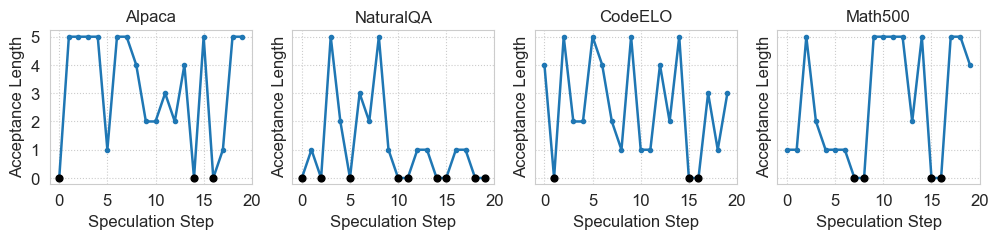

In [236]:
def plot_figure_3_acceptance_length_trace_by_dataset():
    fig_name = "figure_3_acceptance_length_trace_by_dataset"
    if not nonempty(trace_df, ["target_model", "method_pretty", "dataset", "speculative_length", "target_accept_len_by_request"], fig_name):
        return

    for target_model in target_models:
        df = filter_target_and_k(trace_df, target_model, methods=["SD"], k=SPECULATIVE_LENGTH)
        df = filter_temperature(df, temp=0, temp_col=temp_col)
        if df.empty:
            print(f"[skip] {fig_name}: no SD k={SPECULATIVE_LENGTH} rows for {target_model}")
            continue

        long_rows = []
        for _, row in df.iterrows():
            series_df = trace_row_to_series(row)
            if series_df.empty:
                continue
            series_df["dataset"] = row["dataset"]
            long_rows.append(series_df)
        if not long_rows:
            print(f"[skip] {fig_name}: no trace series for {target_model}")
            continue

        long_df = pd.concat(long_rows, ignore_index=True).dropna(subset=["target_accept_len"])
        datasets = [d for d in DATASET_ORDER if d in set(long_df["dataset"])]
        datasets += [d for d in sorted_datasets(long_df["dataset"].unique()) if d not in datasets]
        datasets = datasets[:4]

        fig, axes = plt.subplots(1, len(datasets), figsize=(12, 2), sharey=True)
        if len(datasets) == 1:
            axes = [axes]

        for ax, dataset in zip(axes, datasets):
            sub_all = long_df[long_df["dataset"] == dataset].copy()
            request = sorted(sub_all["request"].unique())[0]
            sub = sub_all[sub_all["request"] == request].sort_values("step_id")
            ax.plot(sub["step_id"], sub["target_accept_len"], marker="o", linewidth=1.8, markersize=3)
            miss = sub[sub["target_accept_len"] == 0]
            if not miss.empty:
                ax.scatter(miss["step_id"], miss["target_accept_len"], s=24, color="black", zorder=5)
            ax.set_title(dataset, fontsize=12)
            ax.set_xlabel("Speculation Step", fontsize=12)
            ax.set_xticks([0, 5, 10, 15, 20])
            ax.set_yticks([0, 1, 2, 3, 4, 5])
            ax.set_xlim(left=0 - 1, right=20)
            ax.set_ylim(bottom=-0.2)
            ax.tick_params(axis="both", which="major", labelsize=12)
            ax.grid(True, linestyle=":")
            ax.set_ylabel("Acceptance Length", fontsize=12)
        # axes[0].set_ylabel("Acceptance Length", fontsize=12)
        save_fig(fig, get_target_out_dir(target_model), f"{fig_name}_k{SPECULATIVE_LENGTH}")
        plt.show()

plot_figure_3_acceptance_length_trace_by_dataset()


## Figure 4. Misspeculation probability by dataset


[figure_4_misspeculation_probability_by_dataset_sd_only] temp=0.0, k=5
  overall geomean misspeculation = 0.213299 (21.33%)
  Llama geomean misspeculation = 0.168915 (16.89%)
  Qwen geomean misspeculation = 0.269346 (26.93%)
  dataset=Alpaca     model=Llama misspeculation=0.186614 (18.66%)
  dataset=Alpaca     model=Qwen  misspeculation=0.311282 (31.13%)
  dataset=CodeELO    model=Llama misspeculation=0.194127 (19.41%)
  dataset=CodeELO    model=Qwen  misspeculation=0.270265 (27.03%)
  dataset=Math500    model=Llama misspeculation=0.122188 (12.22%)
  dataset=Math500    model=Qwen  misspeculation=0.172183 (17.22%)
  dataset=NaturalQA  model=Llama misspeculation=0.183912 (18.39%)
  dataset=NaturalQA  model=Qwen  misspeculation=0.363338 (36.33%)
saved: plots_results/pivot_motivation/motiv1_temp0p0_k5_misspec.pdf
saved: plots_results/pivot_motivation/motiv1_temp0p0_k5_misspec.png


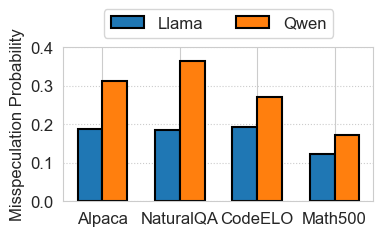


[figure_4_misspeculation_probability_by_dataset_sd_only] temp=0.3, k=5
  overall geomean misspeculation = 0.219060 (21.91%)
  Llama geomean misspeculation = 0.175979 (17.60%)
  Qwen geomean misspeculation = 0.272688 (27.27%)
  dataset=Alpaca     model=Llama misspeculation=0.195785 (19.58%)
  dataset=Alpaca     model=Qwen  misspeculation=0.323310 (32.33%)
  dataset=CodeELO    model=Llama misspeculation=0.196523 (19.65%)
  dataset=CodeELO    model=Qwen  misspeculation=0.272069 (27.21%)
  dataset=Math500    model=Llama misspeculation=0.121193 (12.12%)
  dataset=Math500    model=Qwen  misspeculation=0.175116 (17.51%)
  dataset=NaturalQA  model=Llama misspeculation=0.205674 (20.57%)
  dataset=NaturalQA  model=Qwen  misspeculation=0.358956 (35.90%)
saved: plots_results/pivot_motivation/motiv1_temp0p3_k5_misspec.pdf
saved: plots_results/pivot_motivation/motiv1_temp0p3_k5_misspec.png


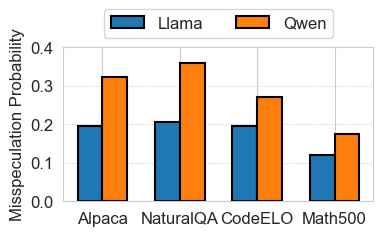


[figure_4_misspeculation_probability_by_dataset_sd_only] temp=0.7, k=5
  overall geomean misspeculation = 0.243992 (24.40%)
  Llama geomean misspeculation = 0.206812 (20.68%)
  Qwen geomean misspeculation = 0.287856 (28.79%)
  dataset=Alpaca     model=Llama misspeculation=0.222952 (22.30%)
  dataset=Alpaca     model=Qwen  misspeculation=0.333319 (33.33%)
  dataset=CodeELO    model=Llama misspeculation=0.225461 (22.55%)
  dataset=CodeELO    model=Qwen  misspeculation=0.312441 (31.24%)
  dataset=Math500    model=Llama misspeculation=0.150891 (15.09%)
  dataset=Math500    model=Qwen  misspeculation=0.173888 (17.39%)
  dataset=NaturalQA  model=Llama misspeculation=0.241187 (24.12%)
  dataset=NaturalQA  model=Qwen  misspeculation=0.379143 (37.91%)
saved: plots_results/pivot_motivation/motiv1_temp0p7_k5_misspec.pdf
saved: plots_results/pivot_motivation/motiv1_temp0p7_k5_misspec.png


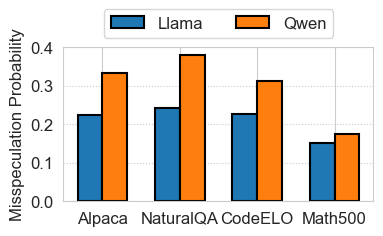

In [237]:
# Temp = 0.3, 0.7

def plot_figure_4_misspeculation_probability_by_dataset():
    fig_name = "figure_4_misspeculation_probability_by_dataset_sd_only"
    prob_col = require_any_col(motivation_df, ["misspeculation_probability"], fig_name)

    if prob_col is None or not nonempty(
        motivation_df,
        ["target_model", "method_pretty", "dataset", prob_col],
        fig_name,
    ):
        return

    
    if temp_col is None:
        print(f"[warn] {fig_name}: no temperature column found. Available columns:")
        print(list(motivation_df.columns))
        return

    for temp in TEMPERATURES:
        temp_df = filter_temperature(motivation_df, temp=temp, temp_col=temp_col)

        if temp_df.empty:
            print(f"[skip] {fig_name}: no rows for temp={temp}")
            continue

        rows = []

        for target_model in target_models:
            df = filter_target_and_k(
                temp_df,
                target_model,
                methods=["SD"],
                k=SPECULATIVE_LENGTH,
            )

            if df.empty:
                print(f"[skip] {fig_name}: no SD rows for {target_model}, temp={temp}")
                continue

            label = target_model_family_label(target_model)
            if label is None:
                print(f"[skip] {fig_name}: unsupported target model label for {target_model}")
                continue

            df = df.copy()
            df["target_label"] = label
            rows.append(df)

        if not rows:
            print(f"[skip] {fig_name}: no Llama/Qwen SD rows for temp={temp}")
            continue

        df = pd.concat(rows, ignore_index=True)

        agg = df.groupby(["dataset", "target_label"], as_index=False)[prob_col].mean()
        agg = df.groupby(["dataset", "target_label"], as_index=False)[prob_col].mean()

        overall_gmean = geometric_mean(agg[prob_col].to_numpy())
        family_gmeans = (
            agg.groupby("target_label")[prob_col]
            .apply(lambda s: geometric_mean(s.to_numpy()))
        )
        
        print(f"\n[{fig_name}] temp={temp}, k={SPECULATIVE_LENGTH}")
        print(
            f"  overall geomean misspeculation = {overall_gmean:.6f} "
            f"({overall_gmean * 100:.2f}%)"
        )
        
        for family, g in family_gmeans.items():
            print(f"  {family} geomean misspeculation = {g:.6f} ({g * 100:.2f}%)")
        
        for _, r in agg.sort_values(["dataset", "target_label"]).iterrows():
            print(
                f"  dataset={r['dataset']:<10} "
                f"model={r['target_label']:<5} "
                f"misspeculation={float(r[prob_col]):.6f} "
                f"({float(r[prob_col]) * 100:.2f}%)"
            )
        datasets = sorted_datasets(agg["dataset"].unique())
        model_labels = [label for label in ["Llama", "Qwen"] if label in set(agg["target_label"])]
        
        x = np.arange(len(datasets))
        width = 0.32

        fig, ax = plt.subplots(figsize=(4, 2))

        for i, label in enumerate(model_labels):
            vals = []
            for dataset in datasets:
                sub = agg[
                    (agg["dataset"] == dataset)
                    & (agg["target_label"] == label)
                ]
                vals.append(np.nan if sub.empty else float(sub[prob_col].iloc[0]))

            offset = (i - (len(model_labels) - 1) / 2) * width

            ax.bar(
                x + offset,
                vals,
                width=width,
                label=label,
                edgecolor="black",
                linewidth=1.5,
            )

        ax.set_xticks(x)
        ax.set_xticklabels(datasets)
        ax.set_ylim(0, 0.4)

        style_axis(
            ax,
            ylabel="Misspeculation Probability",
        )

        legend_top(ax, ncol=len(model_labels), y=1.3, fontsize=12)

        save_fig(
            fig,
            "./plots_results/pivot_motivation",
            f"motiv1_temp{safe_temp_label(temp)}_k{SPECULATIVE_LENGTH}_misspec",
        )

        plt.show()

plot_figure_4_misspeculation_probability_by_dataset()

## Figure 5. Oracle Throughput and Accetpance Length 
### (Assuming misspeculation -> perfect speculation)


[figure_5_oracle_normalized_committed_length_sd_only_by_model] y-values for method=Llama
  dataset=Alpaca       method=Llama         normalized_committed_length=1.000000
  dataset=NaturalQA    method=Llama         normalized_committed_length=1.000000
  dataset=CodeELO      method=Llama         normalized_committed_length=1.000000
  dataset=Math500      method=Llama         normalized_committed_length=1.000000
  geomean method=Llama         normalized_committed_length=1.000000

[figure_5_oracle_normalized_committed_length_sd_only_by_model] y-values for method=Llama-Oracle
  dataset=Alpaca       method=Llama-Oracle  normalized_committed_length=1.255643
  dataset=NaturalQA    method=Llama-Oracle  normalized_committed_length=1.267014
  dataset=CodeELO      method=Llama-Oracle  normalized_committed_length=1.267336
  dataset=Math500      method=Llama-Oracle  normalized_committed_length=1.146431
  geomean method=Llama-Oracle  normalized_committed_length=1.233025

[figure_5_oracle_normalized_

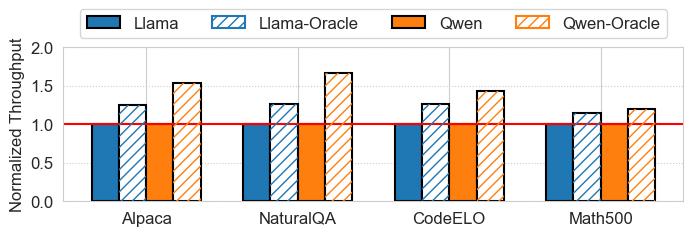


[figure_5_oracle_raw_committed_length_sd_only_by_model] y-values for method=Llama
  dataset=Alpaca       method=Llama         committed_length=3.919446
  dataset=NaturalQA    method=Llama         committed_length=3.893086
  dataset=CodeELO      method=Llama         committed_length=3.842172
  dataset=Math500      method=Llama         committed_length=4.614974
  geomean method=Llama         committed_length=4.055703

[figure_5_oracle_raw_committed_length_sd_only_by_model] y-values for method=Llama-Oracle
  dataset=Alpaca       method=Llama-Oracle  committed_length=4.921424
  dataset=NaturalQA    method=Llama-Oracle  committed_length=4.932597
  dataset=CodeELO      method=Llama-Oracle  committed_length=4.869322
  dataset=Math500      method=Llama-Oracle  committed_length=5.290750
  geomean method=Llama-Oracle  committed_length=5.000783

[figure_5_oracle_raw_committed_length_sd_only_by_model] y-values for method=Qwen
  dataset=Alpaca       method=Qwen          committed_length=3.016322
 

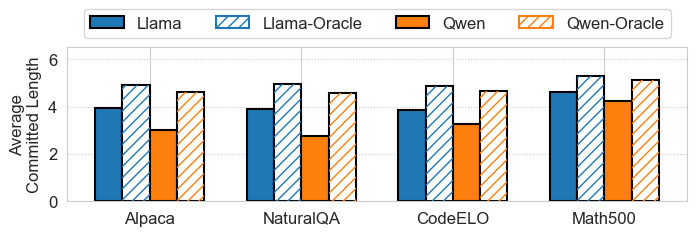

In [240]:
from matplotlib.patches import Patch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

FIGURE_5_METHODS = ["Llama", "Llama-Oracle", "Qwen", "Qwen-Oracle"]

base_methods = ["Llama", "Qwen"]
base_colors = color_map(base_methods)

method_colors = {
    "Llama": base_colors["Llama"],
    "Llama-Oracle": "white",
    "Qwen": base_colors["Qwen"],
    "Qwen-Oracle": "white",
}

method_edges = {
    "Llama": "black",
    "Llama-Oracle": base_colors["Llama"],
    "Qwen": "black",
    "Qwen-Oracle": base_colors["Qwen"],
}

method_hatches = {
    "Llama": "",
    "Llama-Oracle": "///",
    "Qwen": "",
    "Qwen-Oracle": "///",
}

legend_handles = [
    Patch(
        facecolor=base_colors["Llama"],
        edgecolor="black",
        linewidth=1.5,
        label="Llama",
    ),
    Patch(
        facecolor="white",
        edgecolor=base_colors["Llama"],
        hatch="///",
        linewidth=1.5,
        label="Llama-Oracle",
    ),
    Patch(
        facecolor=base_colors["Qwen"],
        edgecolor="black",
        linewidth=1.5,
        label="Qwen",
    ),
    Patch(
        facecolor="white",
        edgecolor=base_colors["Qwen"],
        hatch="///",
        linewidth=1.5,
        label="Qwen-Oracle",
    ),
]


def target_model_family_label(target_model):
    name = str(target_model).lower()
    if "llama" in name:
        return "Llama"
    if "qwen" in name:
        return "Qwen"
    return None


def _row_number_safe(row, col, default=np.nan):
    if col is None:
        return default

    try:
        value = row[col]
    except Exception:
        return default

    if value is None:
        return default

    try:
        value = float(value)
    except Exception:
        return default

    return value if np.isfinite(value) else default


def _get_oracle_committed_length(row):
    """
    Supports both flattened and nested collect_results formats.

    Accepted formats:
      row["oracle_avg_committed_length"]
      row["oracle_acceptance_length"]["oracle_avg_committed_length"]
      row["oracle_acceptance_length.oracle_avg_committed_length"]
    """
    if "oracle_avg_committed_length" in row.index:
        value = row["oracle_avg_committed_length"]
        if value is not None and not isinstance(value, dict):
            try:
                return float(value)
            except Exception:
                pass

    if "oracle_acceptance_length.oracle_avg_committed_length" in row.index:
        value = row["oracle_acceptance_length.oracle_avg_committed_length"]
        try:
            return float(value)
        except Exception:
            pass

    if "oracle_acceptance_length" in row.index:
        obj = row["oracle_acceptance_length"]
        if isinstance(obj, dict):
            value = obj.get("oracle_avg_committed_length")
            try:
                return float(value)
            except Exception:
                pass

    return np.nan


def _get_sd_accept_len(row):
    """
    SD accepted length without recovery.

    Preferred:
      row["avg_target_accept_len"]

    Fallbacks:
      row["true_avg_accept_len"]
      row["oracle_acceptance_length"]["true_avg_accept_len"]
      row["oracle_acceptance_length.true_avg_accept_len"]
    """
    for col in [
        "avg_target_accept_len",
        "true_avg_accept_len",
        "oracle_acceptance_length.true_avg_accept_len",
    ]:
        if col in row.index:
            value = row[col]
            try:
                value = float(value)
                if np.isfinite(value):
                    return value
            except Exception:
                pass

    if "oracle_acceptance_length" in row.index:
        obj = row["oracle_acceptance_length"]
        if isinstance(obj, dict):
            value = obj.get("true_avg_accept_len")
            try:
                value = float(value)
                if np.isfinite(value):
                    return value
            except Exception:
                pass

    return np.nan


def _filter_sd_target_k(df, target_model, k):
    sub = df[df["target_model"] == target_model].copy()

    if "speculative_length" in sub.columns:
        sub = sub[sub["speculative_length"] == k]

    if "method_pretty" in sub.columns:
        sub = sub[sub["method_pretty"].astype(str).str.lower().isin(["sd", "speculative decoding"])]
    elif "method" in sub.columns:
        sub = sub[
            sub["method"].astype(str).str.lower().isin(
                [
                    "sd",
                    "speculative",
                    "speculative_decoding",
                    "speculative decoding",
                    "draft_model",
                ]
            )
        ]

    return sub


def build_committed_length_plot_df(df):
    rows = []

    for target_model in target_models:
        label = target_model_family_label(target_model)
        if label is None:
            print(f"[skip] unsupported target model: {target_model}")
            continue

        sub = _filter_sd_target_k(
            df=df,
            target_model=target_model,
            k=SPECULATIVE_LENGTH,
        )

        if sub.empty:
            print(f"[skip] missing SD rows for {target_model}")
            continue

        for _, row in sub.iterrows():
            dataset = row["dataset"]

            sd_accept_len = _get_sd_accept_len(row)
            sd_committed_len = sd_accept_len + 1.0

            oracle_committed_len = _get_oracle_committed_length(row)

            if not np.isfinite(sd_committed_len):
                continue

            rows.append(
                {
                    "dataset": dataset,
                    "method": label,
                    "committed_length": sd_committed_len,
                }
            )

            if np.isfinite(oracle_committed_len):
                rows.append(
                    {
                        "dataset": dataset,
                        "method": f"{label}-Oracle",
                        "committed_length": oracle_committed_len,
                    }
                )

    plot_df = pd.DataFrame(rows)

    if plot_df.empty:
        return plot_df

    plot_df = (
        plot_df
        .groupby(["dataset", "method"], as_index=False)["committed_length"]
        .mean()
    )

    return plot_df


def _draw_committed_length_bars(
    plot_df,
    fig_name,
    normalized,
    output_name,
):
    if plot_df.empty:
        print(f"[skip] {fig_name}: empty plot_df")
        return

    datasets = sorted_datasets(plot_df["dataset"].unique())
    methods = [m for m in FIGURE_5_METHODS if m in set(plot_df["method"])]

    x = np.arange(len(datasets))
    width = 0.18

    fig, ax = plt.subplots(figsize=(8, 2))

    all_vals = []

    for i, method in enumerate(methods):
        vals = []

        for dataset in datasets:
            sub = plot_df[
                (plot_df["dataset"] == dataset)
                & (plot_df["method"] == method)
            ]

            if sub.empty:
                vals.append(np.nan)
                continue

            value = float(sub["committed_length"].iloc[0])

            if normalized:
                family = method.replace("-Oracle", "")
                base = plot_df[
                    (plot_df["dataset"] == dataset)
                    & (plot_df["method"] == family)
                ]

                if base.empty:
                    vals.append(np.nan)
                    continue

                base_value = float(base["committed_length"].iloc[0])

                if base_value <= 0:
                    vals.append(np.nan)
                else:
                    vals.append(value / base_value)
            else:
                vals.append(value)

        all_vals.extend([v for v in vals if np.isfinite(v)])

        metric_name = "normalized_committed_length" if normalized else "committed_length"

        print(f"\n[{fig_name}] y-values for method={method}")
        for dataset, y in zip(datasets, vals):
            if np.isfinite(y):
                print(
                    f"  dataset={dataset:<12} "
                    f"method={method:<13} "
                    f"{metric_name}={y:.6f}"
                )

        gmean = geometric_mean(vals)
        print(
            f"  geomean method={method:<13} "
            f"{metric_name}={gmean:.6f}"
        )

        xpos = x + (i - (len(methods) - 1) / 2) * width

        if "Oracle" in method:
            ax.bar(
                xpos,
                vals,
                width=width,
                label=method,
                color="white",
                edgecolor="black",
                linewidth=1.5,
                zorder=2,
            )

            ax.bar(
                xpos,
                vals,
                width=width,
                color="none",
                edgecolor=base_colors[method.replace("-Oracle", "")],
                hatch="///",
                linewidth=0.0,
                zorder=3,
            )
        else:
            ax.bar(
                xpos,
                vals,
                width=width,
                label=method,
                color=method_colors[method],
                edgecolor="black",
                linewidth=1.5,
                zorder=2,
            )

    ax.set_xticks(x)
    ax.set_xticklabels(datasets)

    ylabel = "Normalized Throughput" if normalized else "Average\nCommitted Length"

    style_axis(
        ax,
        ylabel=ylabel,
    )

    if normalized:
        ax.axhline(
            y=1.0,
            color="red",
            linestyle="-",
            linewidth=1.5,
        )
        ax.set_yticks([0.0, 0.5, 1.0, 1.5, 2.0])
        ax.set_ylim(0.0, 2.0)
    else:
        if len(all_vals) > 0:
            ymax = max(all_vals)
            ymax = max(1.0, np.ceil(ymax * 1.15 * 2) / 2)
            ax.set_ylim(0.0, ymax)

    ax.legend(
        handles=legend_handles,
        ncol=4,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.3),
        fontsize=12,
        frameon=True,
    )

    save_fig(
        fig,
        "./plots_results/pivot_motivation",
        output_name,
    )

    plt.show()


def plot_figure_5_oracle_committed_length_from_df(df):
    plot_df = build_committed_length_plot_df(df)

    _draw_committed_length_bars(
        plot_df=plot_df,
        fig_name="figure_5_oracle_normalized_committed_length_sd_only_by_model",
        normalized=True,
        output_name=f"motiv2_temp0_k{SPECULATIVE_LENGTH}_oracle_committed_length_normalized",
    )

    _draw_committed_length_bars(
        plot_df=plot_df,
        fig_name="figure_5_oracle_raw_committed_length_sd_only_by_model",
        normalized=False,
        output_name=f"motiv2_temp0_k{SPECULATIVE_LENGTH}_oracle_committed_length_raw",
    )


plot_figure_5_oracle_committed_length_from_df(insight_df)

## Figure 5-1. Markov Chain


[figure_markov_chain_by_family] Llama
        0       1       2       3       4       5
0  0.2705  0.1721  0.1150  0.0807  0.0636  0.2982
1  0.2617  0.1685  0.1108  0.0840  0.0597  0.3153
2  0.2382  0.1637  0.1100  0.0867  0.0629  0.3385
3  0.2358  0.1674  0.1094  0.0795  0.0627  0.3453
4  0.2230  0.1602  0.1057  0.0812  0.0622  0.3677
5  0.1056  0.0867  0.0719  0.0577  0.0496  0.6285

[figure_markov_chain_by_family] Qwen
        0       1       2       3       4       5
0  0.3462  0.2037  0.1258  0.0791  0.0547  0.1905
1  0.3353  0.2006  0.1202  0.0799  0.0580  0.2060
2  0.3229  0.1930  0.1262  0.0806  0.0551  0.2222
3  0.3110  0.1892  0.1176  0.0815  0.0575  0.2432
4  0.2977  0.1934  0.1187  0.0818  0.0560  0.2525
5  0.1734  0.1223  0.0882  0.0688  0.0561  0.4912


/var/folders/d6/bt54rcvj3r5119qfm5079ybh0000gn/T/ipykernel_96694/1238130792.py:217: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


saved: plots_results/pivot_motivation/motiv_markov_chain_temp0_k5_by_family.pdf
saved: plots_results/pivot_motivation/motiv_markov_chain_temp0_k5_by_family.png


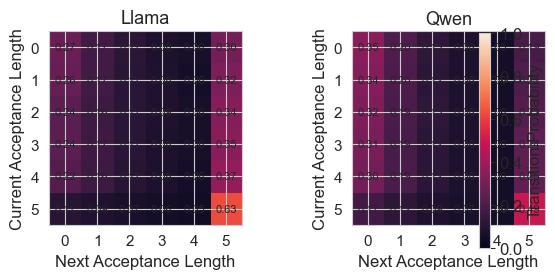

In [244]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def _extract_markov_prob_dict(row):
    """
    Supports both formats:

      row["markov_chain"]["transition_probabilities"]

    and flattened pd.json_normalize format:

      row["markov_chain.transition_probabilities"]
    """
    if "markov_chain.transition_probabilities" in row.index:
        obj = row["markov_chain.transition_probabilities"]
        if isinstance(obj, dict):
            return obj

    if "markov_chain" in row.index:
        obj = row["markov_chain"]
        if isinstance(obj, dict):
            probs = obj.get("transition_probabilities")
            if isinstance(probs, dict):
                return probs

    return None


def _markov_prob_dict_to_matrix(prob_dict, max_state=None):
    """
    Converts:
      {"0": [p00, p01, ...], "1": [p10, p11, ...]}

    into:
      matrix[i, j] = P(next=j | current=i)
    """
    if not isinstance(prob_dict, dict) or len(prob_dict) == 0:
        return None, None

    row_states = []
    for key in prob_dict.keys():
        try:
            row_states.append(int(key))
        except Exception:
            pass

    if len(row_states) == 0:
        return None, None

    inferred_max_row = max(row_states)
    inferred_max_col = max(
        len(v) for v in prob_dict.values()
        if isinstance(v, list)
    ) - 1

    if max_state is None:
        max_state = max(inferred_max_row, inferred_max_col)

    states = list(range(max_state + 1))
    matrix = np.full((len(states), len(states)), np.nan)

    for i in states:
        probs = prob_dict.get(str(i))
        if not isinstance(probs, list):
            continue

        for j in states:
            if j < len(probs):
                value = probs[j]
                if value is not None:
                    matrix[i, j] = float(value)

    return matrix, states


def _filter_sd_target_k(df, target_model, k):
    sub = df[df["target_model"] == target_model].copy()

    if "speculative_length" in sub.columns:
        sub = sub[sub["speculative_length"] == k]

    if "method_pretty" in sub.columns:
        sub = sub[sub["method_pretty"].astype(str).str.lower().isin(["sd", "speculative decoding"])]
    elif "method" in sub.columns:
        sub = sub[
            sub["method"].astype(str).str.lower().isin(
                [
                    "sd",
                    "speculative",
                    "speculative_decoding",
                    "speculative decoding",
                    "draft_model",
                ]
            )
        ]

    return sub


def build_markov_matrix_df(insight_df, max_state=None):
    rows = []

    for target_model in target_models:
        family = target_model_family_label(target_model)
        if family is None:
            print(f"[skip] unsupported target model: {target_model}")
            continue

        sub = _filter_sd_target_k(
            df=insight_df,
            target_model=target_model,
            k=SPECULATIVE_LENGTH,
        )

        if sub.empty:
            print(f"[skip] missing SD rows for {target_model}")
            continue

        for _, row in sub.iterrows():
            prob_dict = _extract_markov_prob_dict(row)
            matrix, states = _markov_prob_dict_to_matrix(prob_dict, max_state=max_state)

            if matrix is None:
                print(f"[skip] missing markov_chain for {target_model}, dataset={row.get('dataset')}")
                continue

            rows.append(
                {
                    "target_model": target_model,
                    "family": family,
                    "dataset": row["dataset"],
                    "matrix": matrix,
                    "states": states,
                }
            )

    return pd.DataFrame(rows)


def _mean_markov_matrix(matrices):
    stacked = np.stack(matrices, axis=0)
    return np.nanmean(stacked, axis=0)


def plot_markov_chain_heatmap_by_family(insight_df, max_state=None):
    """
    One heatmap per model family.

    Recommended for paper figure:
      Llama average transition matrix
      Qwen average transition matrix
    """
    fig_name = "figure_markov_chain_by_family"

    matrix_df = build_markov_matrix_df(insight_df, max_state=max_state)

    if matrix_df.empty:
        print(f"[skip] {fig_name}: no markov matrices")
        return

    families = [f for f in ["Llama", "Qwen"] if f in set(matrix_df["family"])]
    n = len(families)

    fig, axes = plt.subplots(1, n, figsize=(3.1 * n, 2.8), squeeze=False)
    axes = axes[0]

    last_im = None

    for ax, family in zip(axes, families):
        sub = matrix_df[matrix_df["family"] == family]

        matrix = _mean_markov_matrix(list(sub["matrix"]))
        states = sub["states"].iloc[0]

        last_im = ax.imshow(
            matrix,
            vmin=0.0,
            vmax=1.0,
            aspect="equal",
        )

        ax.set_title(family, fontsize=13)
        ax.set_xlabel("Next Acceptance Length", fontsize=12)
        ax.set_ylabel("Current Acceptance Length", fontsize=12)

        ax.set_xticks(np.arange(len(states)))
        ax.set_yticks(np.arange(len(states)))
        ax.set_xticklabels(states, fontsize=11)
        ax.set_yticklabels(states, fontsize=11)

        for i in range(matrix.shape[0]):
            for j in range(matrix.shape[1]):
                value = matrix[i, j]
                if np.isfinite(value):
                    ax.text(
                        j,
                        i,
                        f"{value:.2f}",
                        ha="center",
                        va="center",
                        fontsize=8,
                    )

        print(f"\n[{fig_name}] {family}")
        print(pd.DataFrame(matrix, index=states, columns=states).round(4))

    fig.colorbar(
        last_im,
        ax=axes,
        fraction=0.046,
        pad=0.04,
        label="Transition Probability",
    )

    fig.tight_layout()

    save_fig(
        fig,
        "./plots_results/pivot_motivation",
        f"motiv_markov_chain_temp0_k{SPECULATIVE_LENGTH}_by_family",
    )

    # plt.show()


plot_markov_chain_heatmap_by_family(insight_df, max_state=SPECULATIVE_LENGTH)

## Figure 6. Target match probability, method = sync

saved: plots_results/Llama-3.3-70B-Instruct__PLUS__Llama-3.2-1B-Instruct/figure_6_target_match_probability_k5.pdf
saved: plots_results/Llama-3.3-70B-Instruct__PLUS__Llama-3.2-1B-Instruct/figure_6_target_match_probability_k5.png


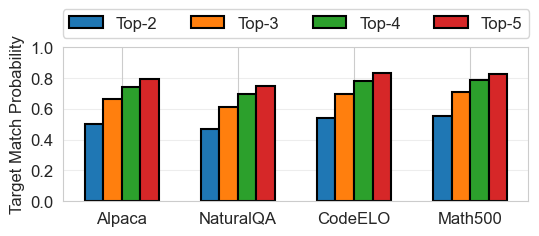

[skip] figure_6_target_match_probability: no sync k=5 rows for Llama-3.3-70B-Instruct+none
saved: plots_results/Qwen3-32B__PLUS__Qwen3-0.6B/figure_6_target_match_probability_k5.pdf
saved: plots_results/Qwen3-32B__PLUS__Qwen3-0.6B/figure_6_target_match_probability_k5.png


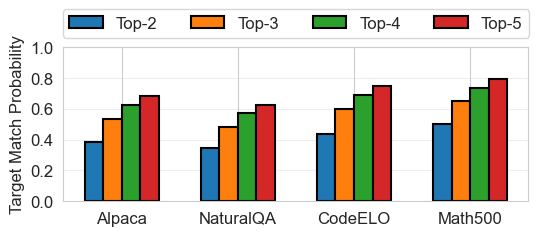

[skip] figure_6_target_match_probability: no sync k=5 rows for Qwen3-32B+none


In [191]:
def plot_figure_6_target_match_probability():
    fig_name = "figure_6_target_match_probability"

    if not nonempty(
        insight_df,
        ["model_pair", "method", "dataset", "speculative_length", "misspeculation_topk_inclusiveness"],
        fig_name,
    ):
        return

    for model_pair in model_pairs:
        df = insight_df[
            (insight_df["model_pair"] == model_pair)
            & (insight_df["method"] == "sync")
            & (insight_df["speculative_length"] == TOPK_SPECULATIVE_LENGTH)
        ].copy()

        if df.empty:
            print(f"[skip] {fig_name}: no sync k={TOPK_SPECULATIVE_LENGTH} rows for {model_pair}")
            continue

        rows = []
        for _, row in df.iterrows():
            base = {
                "dataset": row["dataset"],
                "speculative_length": row["speculative_length"],
            }
            base.update(topk_dict_to_row(row["misspeculation_topk_inclusiveness"]))
            rows.append(base)

        prob_df = pd.DataFrame(rows)
        datasets = sorted_datasets(prob_df["dataset"].unique())

        topks = [f"top{k}_prob" for k in range(2, 6)]
        topk_labels = [f"Top-{k}" for k in range(2, 6)]

        x = np.arange(len(datasets))
        bar_width = 0.16
        colors = color_map(topk_labels)
        
        # fig, ax = plt.subplots(figsize=FIGSIZE_TALL)
        fig, ax = plt.subplots(figsize=(6, 2))
        for i, (col, label) in enumerate(zip(topks, topk_labels)):
            values = [
                prob_df.loc[prob_df["dataset"] == dataset, col].mean()
                for dataset in datasets
            ]
            positions = x - (bar_width * len(topks)) / 2 + i * bar_width + bar_width / 2
            ax.bar(
                positions,
                values,
                width=bar_width,
                label=label,
                color=colors[label],
                edgecolor="black",
                linewidth=1.5,
            )

        ax.set_xticks(x)
        ax.set_xticklabels(datasets)
        # ax.set_xlabel("Dataset")
        ax.set_ylabel("Target Match Probability")
        ax.set_title(None)
        ax.set_ylim(0.0, 1.0)
        ax.set_yticks(np.arange(0.0, 1.01, 0.2))
        ax.grid(True, axis="y", alpha=0.35)

        handles, labels = ax.get_legend_handles_labels()
        by_label = dict(zip(labels, handles))
        ax.legend(
            by_label.values(),
            by_label.keys(),
            loc="upper center",
            bbox_to_anchor=(0.5, 1.3),
            ncol=4,
            fancybox=True,
            shadow=False,
            fontsize=12,
        )

        save_fig(fig, get_model_out_dir(model_pair), f"{fig_name}_k{TOPK_SPECULATIVE_LENGTH}")
        plt.show()

plot_figure_6_target_match_probability()


[figure_1_pivot_static_topk_normalized_throughput] model_pair=Llama-3.3-70B-Instruct+Llama-3.2-1B-Instruct, Top-2
  dataset=Alpaca     Top-2 throughput_normalized=0.880623
  dataset=NaturalQA  Top-2 throughput_normalized=0.845409
  dataset=CodeELO    Top-2 throughput_normalized=0.869904
  dataset=Math500    Top-2 throughput_normalized=0.846207
  geomean Top-2 throughput_normalized=0.860402

[figure_1_pivot_static_topk_normalized_throughput] model_pair=Llama-3.3-70B-Instruct+Llama-3.2-1B-Instruct, Top-3
  dataset=Alpaca     Top-3 throughput_normalized=0.712116
  dataset=NaturalQA  Top-3 throughput_normalized=0.696882
  dataset=CodeELO    Top-3 throughput_normalized=0.731837
  dataset=Math500    Top-3 throughput_normalized=0.690521
  geomean Top-3 throughput_normalized=0.707661

[figure_1_pivot_static_topk_normalized_throughput] model_pair=Llama-3.3-70B-Instruct+Llama-3.2-1B-Instruct, Top-4
  dataset=Alpaca     Top-4 throughput_normalized=0.658224
  dataset=NaturalQA  Top-4 throughput_n

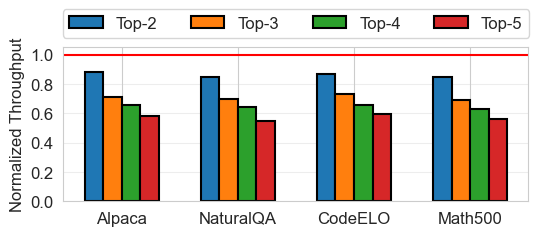


[figure_1_pivot_static_topk_normalized_throughput] model_pair=Qwen3-32B+Qwen3-0.6B, Top-2
  dataset=Alpaca     Top-2 throughput_normalized=0.915338
  dataset=NaturalQA  Top-2 throughput_normalized=0.881005
  dataset=CodeELO    Top-2 throughput_normalized=0.922656
  dataset=Math500    Top-2 throughput_normalized=0.881056
  geomean Top-2 throughput_normalized=0.899810

[figure_1_pivot_static_topk_normalized_throughput] model_pair=Qwen3-32B+Qwen3-0.6B, Top-3
  dataset=Alpaca     Top-3 throughput_normalized=0.743800
  dataset=NaturalQA  Top-3 throughput_normalized=0.729920
  dataset=CodeELO    Top-3 throughput_normalized=0.813167
  dataset=Math500    Top-3 throughput_normalized=0.713541
  geomean Top-3 throughput_normalized=0.749174

[figure_1_pivot_static_topk_normalized_throughput] model_pair=Qwen3-32B+Qwen3-0.6B, Top-4
  dataset=Alpaca     Top-4 throughput_normalized=0.683545
  dataset=NaturalQA  Top-4 throughput_normalized=0.680948
  dataset=CodeELO    Top-4 throughput_normalized=0.72

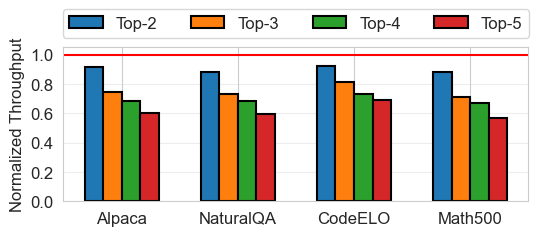

In [192]:
# =========================
# Pivot static top-k figures
# =========================

PIVOT_TOPKS = [2, 3, 4, 5]
PIVOT_TOPK_LABELS = [f"Top-{k}" for k in PIVOT_TOPKS]

PIVOT_POLICY = "static"
PIVOT_FIG_TEMP = None  # temp별로 그리고 싶으면 0.0, 0.3, 0.7 중 하나로 설정


def _filter_temp_if_needed(df, temp=PIVOT_FIG_TEMP):
    if temp is None or "temperature" not in df.columns:
        return df.copy()

    out = df.copy()
    temp_values = pd.to_numeric(out["temperature"], errors="coerce")
    return out[np.isclose(temp_values, float(temp))].copy()


def _pivot_static_rows(df):
    out = df.copy()

    out = out[out["method_pretty"] == "Pivot"].copy()

    if "pivot_expansion_policy" in out.columns:
        out = out[
            out["pivot_expansion_policy"]
            .astype(str)
            .str.lower()
            .eq(PIVOT_POLICY)
        ].copy()

    if "speculative_length" in out.columns:
        out = out[out["speculative_length"] == SPECULATIVE_LENGTH].copy()

    out = _filter_temp_if_needed(out)

    return out


def _sd_baseline_rows(df):
    out = df.copy()

    out = out[out["method_pretty"] == "SD"].copy()

    if "speculative_length" in out.columns:
        out = out[out["speculative_length"] == SPECULATIVE_LENGTH].copy()

    out = _filter_temp_if_needed(out)

    return out


def _valid_pivot_model_pairs(df):
    pivot_df = _pivot_static_rows(df)

    if pivot_df.empty:
        return []

    pairs = []
    for model_pair in sorted(pivot_df["model_pair"].dropna().unique()):
        sd = _sd_baseline_rows(df[df["model_pair"] == model_pair])
        pivot = pivot_df[pivot_df["model_pair"] == model_pair]

        if not sd.empty and not pivot.empty:
            pairs.append(model_pair)

    return pairs


def geometric_mean(values, eps=1e-12):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    if len(values) == 0:
        return np.nan

    values = np.clip(values, eps, None)
    return float(np.exp(np.mean(np.log(values))))


def plot_pivot_static_topk_normalized_metric(
    metric_col,
    ylabel,
    fig_name,
    y_max=1.4,
):
    required = [
        "model_pair",
        "dataset",
        "method_pretty",
        "speculative_length",
        "pivot_expansion_policy",
        "pivot_topk",
        metric_col,
    ]

    if not nonempty(results_df, required, fig_name):
        return

    pivot_model_pairs = _valid_pivot_model_pairs(results_df)

    if not pivot_model_pairs:
        print(f"[skip] {fig_name}: no model_pair with both SD baseline and Pivot static rows")
        return

    colors = color_map(PIVOT_TOPK_LABELS)

    for model_pair in pivot_model_pairs:
        base_df = _sd_baseline_rows(
            results_df[results_df["model_pair"] == model_pair].copy()
        )

        pivot_df_all = _pivot_static_rows(
            results_df[results_df["model_pair"] == model_pair].copy()
        )

        if base_df.empty:
            print(f"[skip] {fig_name}: no SD baseline rows for {model_pair}")
            continue

        if pivot_df_all.empty:
            print(f"[skip] {fig_name}: no Pivot static rows for {model_pair}")
            continue

        base_agg = (
            base_df
            .dropna(subset=[metric_col])
            .groupby("dataset", as_index=False)[metric_col]
            .mean()
            .rename(columns={metric_col: "base_value"})
        )

        rows = []

        for topk in PIVOT_TOPKS:
            pivot_df = pivot_df_all[
                pd.to_numeric(pivot_df_all["pivot_topk"], errors="coerce").eq(topk)
            ].copy()

            if pivot_df.empty:
                print(f"[skip] {fig_name}: no Pivot static Top{topk} rows for {model_pair}")
                continue

            pivot_agg = (
                pivot_df
                .dropna(subset=[metric_col])
                .groupby("dataset", as_index=False)[metric_col]
                .mean()
                .rename(columns={metric_col: "pivot_value"})
            )

            merged = pivot_agg.merge(base_agg, on="dataset", how="inner")

            if merged.empty:
                print(f"[skip] {fig_name}: no merged Top{topk} rows for {model_pair}")
                continue

            merged["topk"] = topk
            merged["topk_label"] = f"Top-{topk}"
            merged["normalized_value"] = merged["pivot_value"] / merged["base_value"]

            rows.append(merged)

        if not rows:
            print(f"[skip] {fig_name}: no rows to plot for {model_pair}")
            continue

        plot_df = pd.concat(rows, ignore_index=True)

        datasets = [d for d in DATASET_ORDER if d in set(plot_df["dataset"])]
        datasets += [
            d for d in sorted_datasets(plot_df["dataset"].unique())
            if d not in datasets
        ]

        topk_labels = [
            label for label in PIVOT_TOPK_LABELS
            if label in set(plot_df["topk_label"])
        ]

        x = np.arange(len(datasets))
        bar_width = 0.16

        fig, ax = plt.subplots(figsize=(6, 2))

        for i, label in enumerate(topk_labels):
            values = []

            for dataset in datasets:
                sub = plot_df[
                    (plot_df["dataset"] == dataset)
                    & (plot_df["topk_label"] == label)
                ]

                if sub.empty:
                    values.append(np.nan)
                else:
                    values.append(float(sub["normalized_value"].iloc[0]))

            print(f"\n[{fig_name}] model_pair={model_pair}, {label}")
            for dataset, y in zip(datasets, values):
                print(
                    f"  dataset={dataset:<10} "
                    f"{label:<5} "
                    f"{metric_col}_normalized={y:.6f}"
                )

            gmean = geometric_mean(values)
            print(f"  geomean {label:<5} {metric_col}_normalized={gmean:.6f}")

            positions = (
                x
                - (bar_width * len(topk_labels)) / 2
                + i * bar_width
                + bar_width / 2
            )

            ax.bar(
                positions,
                values,
                width=bar_width,
                label=label,
                color=colors[label],
                edgecolor="black",
                linewidth=1.5,
            )

        ax.set_xticks(x)
        ax.set_xticklabels(datasets)
        ax.set_ylabel(ylabel)
        ax.set_ylim(0.0, 1.05)
        ax.set_yticks(np.arange(0.0, 1.05, 0.2))

        ax.axhline(
            y=1.0,
            color="red",
            linestyle="-",
            linewidth=1.5,
        )

        ax.grid(True, axis="y", alpha=0.35)

        handles, labels = ax.get_legend_handles_labels()
        by_label = dict(zip(labels, handles))
        ax.legend(
            by_label.values(),
            by_label.keys(),
            loc="upper center",
            bbox_to_anchor=(0.5, 1.3),
            ncol=4,
            fancybox=True,
            shadow=False,
            fontsize=12,
        )

        temp_suffix = "" if PIVOT_FIG_TEMP is None else f"_temp{safe_temp_label(PIVOT_FIG_TEMP)}"

        save_fig(
            fig,
            get_model_out_dir(model_pair),
            f"{fig_name}{temp_suffix}_k{SPECULATIVE_LENGTH}",
        )

        plt.show()


def plot_figure_1_pivot_static_topk_normalized_throughput():
    plot_pivot_static_topk_normalized_metric(
        metric_col="throughput",
        ylabel="Normalized Throughput",
        fig_name="figure_1_pivot_static_topk_normalized_throughput",
        y_max=1.4,
    )


def plot_figure_2_pivot_static_topk_normalized_target_verification():
    plot_pivot_static_topk_normalized_metric(
        metric_col="num_target_verification",
        ylabel="Normalized Target\nVerification",
        fig_name="figure_2_pivot_static_topk_normalized_target_verification",
        y_max=1.6,
    )


plot_figure_1_pivot_static_topk_normalized_throughput()


In [222]:
# plot_figure_2_pivot_static_topk_normalized_target_verification()

In [223]:
# Check what data we have

# print("results columns")
# print(results_df.columns.tolist())

# print("motivation columns")
# print(motivation_df.columns.tolist())

# print("results method_pretty")
# print(results_df["method_pretty"].dropna().unique())

# print("motivation method_pretty")
# print(motivation_df["method_pretty"].dropna().unique())

saved: plots_results/Llama-3.3-70B-Instruct/figure_7_acceptance_length_intrabatch_distribution_by_dataset_k5.pdf
saved: plots_results/Llama-3.3-70B-Instruct/figure_7_acceptance_length_intrabatch_distribution_by_dataset_k5.png


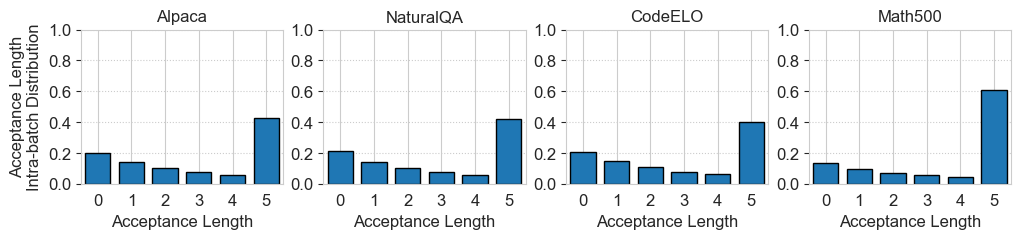

saved: plots_results/Qwen3-32B/figure_7_acceptance_length_intrabatch_distribution_by_dataset_k5.pdf
saved: plots_results/Qwen3-32B/figure_7_acceptance_length_intrabatch_distribution_by_dataset_k5.png


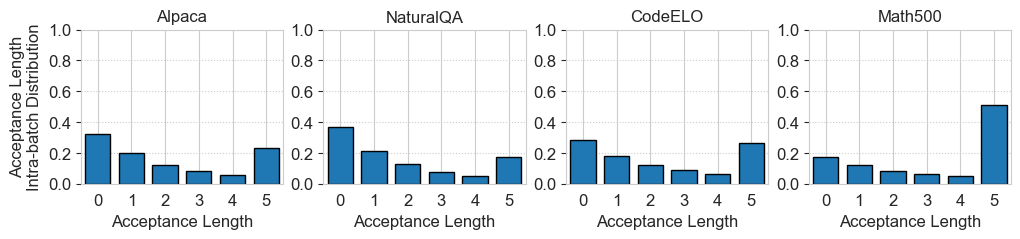

In [195]:
import ast
import json

def _maybe_parse_dist(dist):
    if isinstance(dist, str):
        try:
            return json.loads(dist)
        except Exception:
            try:
                return ast.literal_eval(dist)
            except Exception:
                return None
    return dist


def _batch_accept_dist_to_rows(row, value_col="target_batch_accept_distributions"):
    dist = _maybe_parse_dist(row.get(value_col))
    if dist is None:
        return []

    rows = []

    if isinstance(dist, list):
        for step_id, step_dist in enumerate(dist):
            step_dist = _maybe_parse_dist(step_dist)

            if isinstance(step_dist, dict):
                for accept_len, count in step_dist.items():
                    rows.append({
                        "step_id": step_id,
                        "accept_len": int(accept_len),
                        "count": float(count),
                    })

            elif isinstance(step_dist, list):
                for accept_len, count in enumerate(step_dist):
                    rows.append({
                        "step_id": step_id,
                        "accept_len": int(accept_len),
                        "count": float(count),
                    })

    elif isinstance(dist, dict):
        for accept_len, count in dist.items():
            rows.append({
                "step_id": 0,
                "accept_len": int(accept_len),
                "count": float(count),
            })

    return rows


def plot_figure_7_acceptance_length_intrabatch_distribution_by_dataset():
    fig_name = "figure_7_acceptance_length_intrabatch_distribution_by_dataset"
    required = [
        "target_model",
        "method_pretty",
        "dataset",
        "speculative_length",
        "target_batch_accept_distributions",
    ]

    if not nonempty(motivation_df, required, fig_name):
        return

    for target_model in target_models:
        df = filter_target_and_k(
            motivation_df,
            target_model,
            methods=["SD"],
            k=SPECULATIVE_LENGTH,
        )

        if df.empty:
            print(f"[skip] {fig_name}: no SD k={SPECULATIVE_LENGTH} rows for {target_model}")
            continue

        long_rows = []
        for _, row in df.iterrows():
            for r in _batch_accept_dist_to_rows(row):
                r["dataset"] = row["dataset"]
                long_rows.append(r)

        if not long_rows:
            print(f"[skip] {fig_name}: no target_batch_accept_distributions for {target_model}")
            continue

        long_df = pd.DataFrame(long_rows).dropna(subset=["accept_len", "count"])
        long_df = long_df[
            (long_df["accept_len"] >= 0)
            & (long_df["accept_len"] <= SPECULATIVE_LENGTH)
        ]

        datasets = [d for d in DATASET_ORDER if d in set(long_df["dataset"])]
        datasets += [d for d in sorted_datasets(long_df["dataset"].unique()) if d not in datasets]
        datasets = datasets[:4]

        fig, axes = plt.subplots(1, len(datasets), figsize=(12, 2), sharey=True)
        if len(datasets) == 1:
            axes = [axes]

        x_vals = list(range(SPECULATIVE_LENGTH + 1))

        for ax, dataset in zip(axes, datasets):
            sub = long_df[long_df["dataset"] == dataset].copy()

            dist = (
                sub.groupby("accept_len", as_index=False)["count"]
                .sum()
                .set_index("accept_len")
                .reindex(x_vals, fill_value=0)
                .reset_index()
            )

            total = dist["count"].sum()
            dist["prob"] = dist["count"] / total if total > 0 else 0.0

            ax.bar(
                dist["accept_len"],
                dist["prob"],
                width=0.75,
                edgecolor="black",
                linewidth=1.0,
            )

            ax.set_title(dataset, fontsize=12)
            ax.set_xlabel("Acceptance Length", fontsize=12)
            ax.set_xticks(x_vals)
            ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
            ax.yaxis.set_ticks_position("left")
            ax.tick_params(axis="y", labelleft=True)
            ax.set_xlim(left=-0.5, right=SPECULATIVE_LENGTH + 0.5)
            ax.set_ylim(bottom=0.0, top=1.0)
            ax.tick_params(axis="both", which="major", labelsize=12)
            ax.grid(True, linestyle=":", axis="y")
            
        axes[0].set_ylabel("Acceptance Length\nIntra-batch Distribution", fontsize=12)
        save_fig(
            fig,
            get_target_out_dir(target_model),
            f"{fig_name}_k{SPECULATIVE_LENGTH}",
        )
        plt.show()


plot_figure_7_acceptance_length_intrabatch_distribution_by_dataset()

## Figure 7. Misspeculation confidence correlation, top-1 confidence

[figure_9_misspeculation_residual_confidence] model_pair=Llama-3.3-70B-Instruct+Llama-3.2-1B-Instruct, dataset=Alpaca, residual_confidence: q50=0.207866, q95=0.790146, num_misspec_samples=10208
[figure_9_misspeculation_residual_confidence] model_pair=Llama-3.3-70B-Instruct+Llama-3.2-1B-Instruct, dataset=NaturalQA, residual_confidence: q50=0.176553, q95=0.760283, num_misspec_samples=10761
[figure_9_misspeculation_residual_confidence] model_pair=Llama-3.3-70B-Instruct+Llama-3.2-1B-Instruct, dataset=CodeELO, residual_confidence: q50=0.220459, q95=0.812383, num_misspec_samples=10572
[figure_9_misspeculation_residual_confidence] model_pair=Llama-3.3-70B-Instruct+Llama-3.2-1B-Instruct, dataset=Math500, residual_confidence: q50=0.218728, q95=0.882726, num_misspec_samples=5645
saved: plots_results/Llama-3.3-70B-Instruct__PLUS__Llama-3.2-1B-Instruct/figure_9_misspeculation_residual_confidence_k5.pdf
saved: plots_results/Llama-3.3-70B-Instruct__PLUS__Llama-3.2-1B-Instruct/figure_9_misspeculation

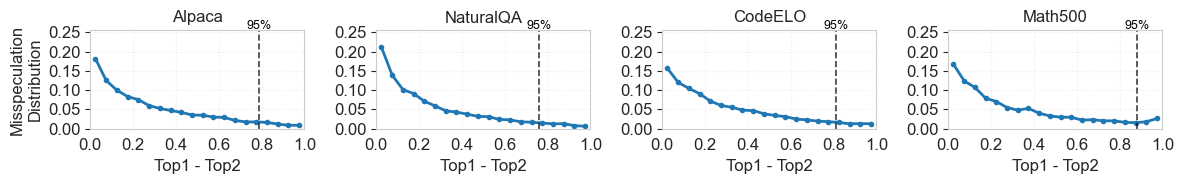

[skip] figure_9_misspeculation_residual_confidence: no sync k=5 rows for Llama-3.3-70B-Instruct+none
[figure_9_misspeculation_residual_confidence] model_pair=Qwen3-32B+Qwen3-0.6B, dataset=Alpaca, residual_confidence: q50=0.221300, q95=0.829739, num_misspec_samples=21139
[figure_9_misspeculation_residual_confidence] model_pair=Qwen3-32B+Qwen3-0.6B, dataset=NaturalQA, residual_confidence: q50=0.212920, q95=0.838089, num_misspec_samples=26375
[figure_9_misspeculation_residual_confidence] model_pair=Qwen3-32B+Qwen3-0.6B, dataset=CodeELO, residual_confidence: q50=0.238785, q95=0.832608, num_misspec_samples=17305
[figure_9_misspeculation_residual_confidence] model_pair=Qwen3-32B+Qwen3-0.6B, dataset=Math500, residual_confidence: q50=0.260716, q95=0.871321, num_misspec_samples=8104
saved: plots_results/Qwen3-32B__PLUS__Qwen3-0.6B/figure_9_misspeculation_residual_confidence_k5.pdf
saved: plots_results/Qwen3-32B__PLUS__Qwen3-0.6B/figure_9_misspeculation_residual_confidence_k5.png


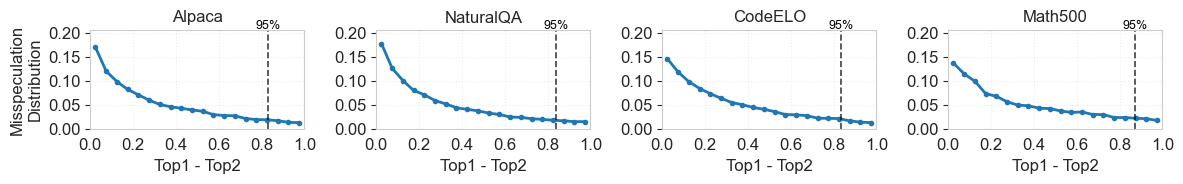

[skip] figure_9_misspeculation_residual_confidence: no sync k=5 rows for Qwen3-32B+none


In [196]:
MISSPEC_CONF_THRESHOLDS = {}
def expand_confidence_rows(df, value_col):
    rows = []

    for _, row in df.iterrows():
        corr_rows = row.get("misspeculation_confidence_correlation")
        if not isinstance(corr_rows, list):
            continue

        for corr in corr_rows:
            if not isinstance(corr, dict):
                continue

            value = corr.get(value_col)
            if value is None:
                continue

            rows.append(
                {
                    "dataset": row["dataset"],
                    "method": row["method"],
                    "speculative_length": row["speculative_length"],
                    "value": value,
                }
            )

    return pd.DataFrame(rows)

def probability_hist_line(values, bins):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    if len(values) == 0:
        centers = (bins[:-1] + bins[1:]) / 2.0
        return centers, np.zeros_like(centers)

    counts, edges = np.histogram(values, bins=bins)
    probs = counts / counts.sum() if counts.sum() > 0 else np.zeros_like(counts, dtype=float)
    centers = (edges[:-1] + edges[1:]) / 2.0

    return centers, probs

def plot_confidence_correlation_by_dataset_row(value_col, xlabel, fig_name):
    if not nonempty(
        insight_df,
        ["model_pair", "method", "dataset", "speculative_length", "misspeculation_confidence_correlation"],
        fig_name,
    ):
        return

    if value_col == "residual_confidence":
        xlabel = "Top1 - Top2"
        # xlabel = "Residual Confidence (Top1 - Top2)"

    for model_pair in model_pairs:
        df = insight_df[
            (insight_df["model_pair"] == model_pair)
            & (insight_df["method"] == "sync")
            & (insight_df["speculative_length"] == CONF_SPECULATIVE_LENGTH)
        ].copy()

        if df.empty:
            print(f"[skip] {fig_name}: no sync k={CONF_SPECULATIVE_LENGTH} rows for {model_pair}")
            continue

        long_df = expand_confidence_rows(df, value_col=value_col)
        if long_df.empty:
            print(f"[skip] {fig_name}: no confidence rows for {model_pair}")
            continue

        datasets = [d for d in DATASET_ORDER if d in set(long_df["dataset"])]
        datasets += [d for d in sorted_datasets(long_df["dataset"].unique()) if d not in datasets]
        datasets = datasets[:4]

        fig, axes = plt.subplots(
            1,
            len(datasets),
            figsize=(12, 2),
            sharex=True,
            sharey=True,
        )
        if len(datasets) == 1:
            axes = [axes]

        line_color = "tab:blue"

        if value_col == "residual_confidence":
            lo = min(0.0, float(long_df["value"].min()))
            hi = max(1.0, float(long_df["value"].max()))
            bins = np.linspace(lo, hi, 21)
        else:
            lo = 0.0
            hi = 1.0
            bins = np.linspace(lo, hi, 21)

        global_ymax = 0.05
        cached = {}

        for dataset in datasets:
            values = long_df.loc[long_df["dataset"] == dataset, "value"].dropna().values
            centers, probs = probability_hist_line(values, bins=bins)
            cached[dataset] = (values, centers, probs)

            if len(probs) > 0:
                global_ymax = max(global_ymax, float(np.nanmax(probs)))

        global_ymax = np.ceil(global_ymax / 0.05) * 0.05
        global_ymax = max(global_ymax, 0.05)

        for ax, dataset in zip(axes, datasets):
            values, centers, probs = cached[dataset]

            ax.plot(
                centers,
                probs,
                marker="o",
                linewidth=2,
                markersize=3,
                color=line_color,
            )

            if len(values) > 0:
                q50 = np.quantile(values, 0.50)
                q95 = np.quantile(values, 0.95)

                MISSPEC_CONF_THRESHOLDS[(model_pair, dataset, value_col)] = {
                    # "50%": q50,
                    "95%": q95,
                }

                print(
                    f"[{fig_name}] model_pair={model_pair}, "
                    f"dataset={dataset}, "
                    f"{value_col}: q50={q50:.6f}, q95={q95:.6f}, "
                    f"num_misspec_samples={len(values)}"
                )

                for q_label, q_value in MISSPEC_CONF_THRESHOLDS[(model_pair, dataset, value_col)].items():
                    ax.axvline(
                        q_value,
                        color="black",
                        linestyle="--",
                        linewidth=1.2,
                        alpha=0.75,
                    )
                    ax.text(
                        q_value,
                        1.1,
                        q_label,
                        transform=ax.get_xaxis_transform(),
                        va="top",
                        ha="center",
                        fontsize=9,
                        color="black",
                    )

            ax.set_title(dataset, fontsize=12)
            ax.set_xlabel(xlabel, fontsize=12)
            

            ax.set_xlim(lo, hi)
            ax.set_xticks(np.linspace(lo, hi, 6))
            ax.set_ylim(0.0, global_ymax + 0.005)
            ax.set_yticks(np.arange(0.0, global_ymax + 1e-9, 0.05))

            ax.tick_params(
                axis="both",
                which="both",
                labelbottom=True,
                labelleft=True,
                labelsize=12,
            )

            ax.yaxis.set_ticks_position("left")
            ax.grid(True, linestyle=":", alpha=0.35)
        fig.tight_layout(rect=[0, 0.08, 1, 1])
        axes[0].set_ylabel("Misspeculation\nDistribution", fontsize=12)
        fig.tight_layout()

        save_fig(fig, get_model_out_dir(model_pair), f"{fig_name}_k{CONF_SPECULATIVE_LENGTH}")
        plt.show()


# plot_confidence_correlation_by_dataset_row(
#     value_col="top1_confidence",
#     xlabel="Top-1 Confidence",
#     fig_name="figure_8_misspeculation_top1_confidence",
# )

plot_confidence_correlation_by_dataset_row(
    value_col="residual_confidence",
    xlabel="Top1 - Top2",
    fig_name="figure_9_misspeculation_residual_confidence",
)


## Figure 8. Misspeculation confidence correlation, residual confidence

[figure_10_sampling_residual_confidence] model_pair=Llama-3.3-70B-Instruct+Llama-3.2-1B-Instruct, dataset=Alpaca, residual_confidence, threshold=0.800000: sampling_prob=0.463487, sampling_percent=46.35%, num_sampling_samples=50448
[figure_10_sampling_residual_confidence] model_pair=Llama-3.3-70B-Instruct+Llama-3.2-1B-Instruct, dataset=NaturalQA, residual_confidence, threshold=0.800000: sampling_prob=0.477139, sampling_percent=47.71%, num_sampling_samples=50872
[figure_10_sampling_residual_confidence] model_pair=Llama-3.3-70B-Instruct+Llama-3.2-1B-Instruct, dataset=CodeELO, residual_confidence, threshold=0.800000: sampling_prob=0.481838, sampling_percent=48.18%, num_sampling_samples=51399
[figure_10_sampling_residual_confidence] model_pair=Llama-3.3-70B-Instruct+Llama-3.2-1B-Instruct, dataset=Math500, residual_confidence, threshold=0.800000: sampling_prob=0.328087, sampling_percent=32.81%, num_sampling_samples=42821
saved: plots_results/Llama-3.3-70B-Instruct__PLUS__Llama-3.2-1B-Instruc

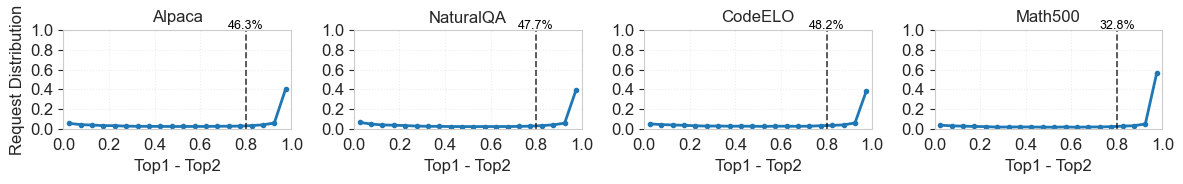

[skip] figure_10_sampling_residual_confidence: no sync k=5 rows for Llama-3.3-70B-Instruct+none
[figure_10_sampling_residual_confidence] model_pair=Qwen3-32B+Qwen3-0.6B, dataset=Alpaca, residual_confidence, threshold=0.800000: sampling_prob=0.599670, sampling_percent=59.97%, num_sampling_samples=65466
[figure_10_sampling_residual_confidence] model_pair=Qwen3-32B+Qwen3-0.6B, dataset=NaturalQA, residual_confidence, threshold=0.800000: sampling_prob=0.637216, sampling_percent=63.72%, num_sampling_samples=71792
[figure_10_sampling_residual_confidence] model_pair=Qwen3-32B+Qwen3-0.6B, dataset=CodeELO, residual_confidence, threshold=0.800000: sampling_prob=0.597755, sampling_percent=59.78%, num_sampling_samples=60575
[figure_10_sampling_residual_confidence] model_pair=Qwen3-32B+Qwen3-0.6B, dataset=Math500, residual_confidence, threshold=0.800000: sampling_prob=0.382468, sampling_percent=38.25%, num_sampling_samples=46647
saved: plots_results/Qwen3-32B__PLUS__Qwen3-0.6B/figure_10_sampling_res

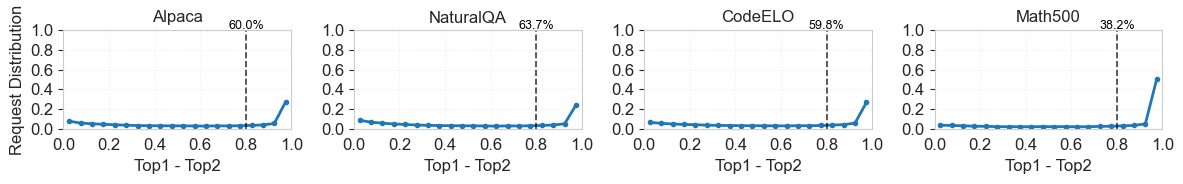

[skip] figure_10_sampling_residual_confidence: no sync k=5 rows for Qwen3-32B+none


In [197]:
def expand_sampling_confidence_rows(df, value_col):
    rows = []

    for _, row in df.iterrows():
        dist_rows = row.get("confidence_distribution")
        if not isinstance(dist_rows, list):
            continue

        for dist in dist_rows:
            if not isinstance(dist, dict):
                continue

            value = dist.get(value_col)
            if value is None:
                continue

            rows.append(
                {
                    "dataset": row["dataset"],
                    "method": row["method"],
                    "speculative_length": row["speculative_length"],
                    "value": value,
                }
            )

    return pd.DataFrame(rows)

def plot_sampling_confidence_distribution_by_dataset_row(value_col, xlabel, fig_name):
    if not nonempty(
        insight_df,
        ["model_pair", "method", "dataset", "speculative_length", "confidence_distribution"],
        fig_name,
    ):
        return

    if value_col == "residual_confidence":
        xlabel = "Top1 - Top2"

    for model_pair in model_pairs:
        df = insight_df[
            (insight_df["model_pair"] == model_pair)
            & (insight_df["method"] == "sync")
            & (insight_df["speculative_length"] == CONF_SPECULATIVE_LENGTH)
        ].copy()

        if df.empty:
            print(f"[skip] {fig_name}: no sync k={CONF_SPECULATIVE_LENGTH} rows for {model_pair}")
            continue

        long_df = expand_sampling_confidence_rows(df, value_col=value_col)
        if long_df.empty:
            print(f"[skip] {fig_name}: no confidence distribution rows for {model_pair}")
            continue

        datasets = [d for d in DATASET_ORDER if d in set(long_df["dataset"])]
        datasets += [d for d in sorted_datasets(long_df["dataset"].unique()) if d not in datasets]
        datasets = datasets[:4]

        fig, axes = plt.subplots(
            1,
            len(datasets),
            figsize=(12, 2),
            sharex=True,
            sharey=True,
        )

        if len(datasets) == 1:
            axes = [axes]

        line_color = "tab:blue"

        if value_col == "residual_confidence":
            lo = min(0.0, float(long_df["value"].min()))
            hi = max(1.0, float(long_df["value"].max()))
            bins = np.linspace(lo, hi, 21)
        else:
            lo = 0.0
            hi = 1.0
            bins = np.linspace(lo, hi, 21)

        cached = {}
        for dataset in datasets:
            values = long_df.loc[long_df["dataset"] == dataset, "value"].dropna().values
            centers, probs = probability_hist_line(values, bins=bins)
            cached[dataset] = (values, centers, probs)

        for ax, dataset in zip(axes, datasets):
            values, centers, probs = cached[dataset]

            ax.plot(
                centers,
                probs,
                marker="o",
                linewidth=2,
                markersize=3,
                color=line_color,
            )

            sampling_prob = np.mean(values <= 0.8) if len(values) > 0 else 0.0

            if lo <= 0.8 <= hi:
                ax.axvline(
                    0.8,
                    color="black",
                    linestyle="--",
                    linewidth=1.2,
                    alpha=0.75,
                )
            
                ax.text(
                    0.8,
                    1.1,
                    f"{sampling_prob * 100:.1f}%",
                    transform=ax.get_xaxis_transform(),
                    va="top",
                    ha="center",
                    fontsize=9,
                    color="black",
                )
            
            if len(values) > 0:
                print(
                    f"[{fig_name}] model_pair={model_pair}, "
                    f"dataset={dataset}, "
                    f"{value_col}, threshold=0.800000: "
                    f"sampling_prob={sampling_prob:.6f}, "
                    f"sampling_percent={sampling_prob * 100:.2f}%, "
                    f"num_sampling_samples={len(values)}"
                )

            ax.set_title(dataset, fontsize=12)
            ax.set_xlabel(xlabel, fontsize=12)

            ax.set_xlim(lo, hi)
            ax.set_xticks(np.linspace(lo, hi, 6))
            ax.set_ylim(0.0, 1.0)
            ax.set_yticks(np.arange(0.0, 1.01, 0.2))

            ax.tick_params(
                axis="both",
                which="both",
                labelbottom=True,
                labelleft=True,
                labelsize=12,
            )

            ax.yaxis.set_ticks_position("left")
            ax.grid(True, linestyle=":", alpha=0.35)

        axes[0].set_ylabel("Request Distribution", fontsize=12)

        fig.tight_layout()

        save_fig(fig, get_model_out_dir(model_pair), f"{fig_name}_k{CONF_SPECULATIVE_LENGTH}")
        plt.show()

# plot_sampling_confidence_distribution_by_dataset_row(
#     value_col="top1_confidence",
#     xlabel="Top-1 Confidence",
#     fig_name="figure_9_sampling_top1_confidence",
# )


plot_sampling_confidence_distribution_by_dataset_row(
    value_col="residual_confidence",
    xlabel="Residual Confidence (Top1 - Top2)",
    fig_name="figure_10_sampling_residual_confidence",
)

## Raw dataframe previews

In [198]:

# display(motivation_df.head())
# display(results_df.head())
# display(insight_df.head())
# display(trace_df.head())


[figure_1_ar_normalized_throughput_with_pivot] target_model=Llama-3.3-70B-Instruct
policy=dynamic, expansion_pct=0.2, k=5, temp=None

method=Auto-regressive
  dataset=Alpaca     raw_throughput=839.966843 normalized_to_ar=1.000000
  dataset=NaturalQA  raw_throughput=841.098968 normalized_to_ar=1.000000
  dataset=CodeELO    raw_throughput=792.175638 normalized_to_ar=1.000000
  dataset=Math500    raw_throughput=853.403722 normalized_to_ar=1.000000
  geomean_normalized_to_ar=1.000000

method=Speculative Decoding
  dataset=Alpaca     raw_throughput=1630.537375 normalized_to_ar=1.941193
  dataset=NaturalQA  raw_throughput=1691.895308 normalized_to_ar=2.011529
  dataset=CodeELO    raw_throughput=1436.291116 normalized_to_ar=1.813097
  dataset=Math500    raw_throughput=1894.535736 normalized_to_ar=2.219976
  geomean_normalized_to_ar=1.991091

method=Pivot-Top2
  dataset=Alpaca     raw_throughput=1543.467058 normalized_to_ar=1.837533
  dataset=NaturalQA  raw_throughput=1584.435579 normalized_t

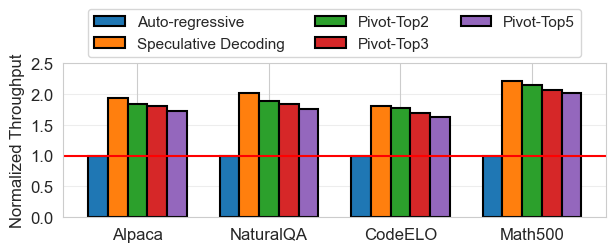


[figure_1_ar_normalized_throughput_with_pivot] target_model=Qwen3-32B
policy=dynamic, expansion_pct=0.2, k=5, temp=None

method=Auto-regressive
  dataset=Alpaca     raw_throughput=972.762199 normalized_to_ar=1.000000
  dataset=NaturalQA  raw_throughput=971.551845 normalized_to_ar=1.000000
  dataset=CodeELO    raw_throughput=906.347281 normalized_to_ar=1.000000
  dataset=Math500    raw_throughput=962.469126 normalized_to_ar=1.000000
  geomean_normalized_to_ar=1.000000

method=Speculative Decoding
  dataset=Alpaca     raw_throughput=1270.239760 normalized_to_ar=1.305807
  dataset=NaturalQA  raw_throughput=1177.169483 normalized_to_ar=1.211638
  dataset=CodeELO    raw_throughput=1131.255398 normalized_to_ar=1.248148
  dataset=Math500    raw_throughput=1671.716622 normalized_to_ar=1.736904
  geomean_normalized_to_ar=1.360891

method=Pivot-Top2
  dataset=Alpaca     raw_throughput=1256.625345 normalized_to_ar=1.291811
  dataset=NaturalQA  raw_throughput=1149.422536 normalized_to_ar=1.183079

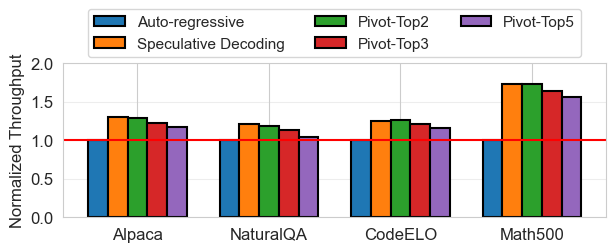

In [213]:
# =========================
# Figure 1, AR-normalized throughput
# AR, SD, Pivot-Top2, Pivot-Top3, Pivot-Top5
# Corrected filtering version
# =========================

AR_NORM_PIVOT_TOPKS = [2, 3, 5]
AR_NORM_EXPANSION_PCT = 0.2
AR_NORM_PIVOT_POLICY = "dynamic"
AR_NORM_TEMP = None   # 예를 들면 0.0, 0.3, 0.7 중 하나로 설정 가능

AR_NORM_METHODS = [
    "Auto-regressive",
    "Speculative Decoding",
    "Pivot-Top2",
    "Pivot-Top3",
    "Pivot-Top5",
]






AR_NORM_METHOD_COLORS = color_map(AR_NORM_METHODS)


def _normalize_expansion_pct(series):
    vals = pd.to_numeric(series, errors="coerce")

    # Some logs store 20% as 20 instead of 0.2.
    vals = vals.where(vals <= 1.0, vals / 100.0)

    return vals


def _filter_temp_optional(df, temp=AR_NORM_TEMP):
    if temp is None:
        return df.copy()

    if "temperature" not in df.columns:
        return df.copy()

    out = df.copy()
    temp_vals = pd.to_numeric(out["temperature"], errors="coerce")
    return out[np.isclose(temp_vals, float(temp))].copy()


def _geomean(values, eps=1e-12):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    if len(values) == 0:
        return np.nan

    values = np.clip(values, eps, None)
    return float(np.exp(np.mean(np.log(values))))


def _filter_ar_rows(df):
    out = df.copy()
    out = out[out["method_pretty"] == "AR"].copy()
    out = _filter_temp_optional(out)
    return out


def _filter_sd_rows(df):
    out = df.copy()
    out = out[out["method_pretty"] == "SD"].copy()

    if "speculative_length" in out.columns:
        out = out[out["speculative_length"] == SPECULATIVE_LENGTH].copy()

    out = _filter_temp_optional(out)
    return out


def _filter_pivot_rows(df):
    out = df.copy()
    out = out[out["method_pretty"] == "Pivot"].copy()

    if "speculative_length" in out.columns:
        out = out[out["speculative_length"] == SPECULATIVE_LENGTH].copy()

    if "pivot_expansion_policy" in out.columns:
        policy = out["pivot_expansion_policy"].astype(str).str.lower()
        out = out[policy.str.contains(AR_NORM_PIVOT_POLICY, na=False)].copy()

    if "pivot_expansion_pct" in out.columns:
        pct = _normalize_expansion_pct(out["pivot_expansion_pct"])
        out = out[np.isclose(pct, AR_NORM_EXPANSION_PCT, atol=1e-6)].copy()

    out = _filter_temp_optional(out)
    return out


def plot_figure_1_ar_normalized_throughput_with_pivot():
    fig_name = "figure_1_ar_normalized_throughput_with_pivot"

    required_cols = [
        "target_model",
        "dataset",
        "method_pretty",
        "throughput",
        "pivot_expansion_pct",
        "pivot_topk",
        "pivot_expansion_policy",
    ]

    if not nonempty(results_df, required_cols, fig_name):
        return

    df_all = results_df.copy()
    df_all = _filter_temp_optional(df_all)

    if df_all.empty:
        print(f"[skip] {fig_name}: no rows after temperature filtering")
        return

    target_models_local = sorted(
        df_all["target_model"]
        .dropna()
        .astype(str)
        .unique()
    )

    for target_model in target_models_local:
        df = df_all[df_all["target_model"].astype(str) == str(target_model)].copy()

        if df.empty:
            print(f"[skip] {fig_name}: no rows for {target_model}")
            continue

        ar_df = _filter_ar_rows(df)
        sd_df = _filter_sd_rows(df)
        pivot_df = _filter_pivot_rows(df)

        if ar_df.empty:
            print(f"[skip] {fig_name}: no AR rows for {target_model}")
            continue

        if sd_df.empty:
            print(
                f"[skip] {fig_name}: no SD rows for {target_model}, "
                f"k={SPECULATIVE_LENGTH}, temp={AR_NORM_TEMP}"
            )
            continue

        if pivot_df.empty:
            print(
                f"[skip] {fig_name}: no Pivot rows for {target_model}, "
                f"policy={AR_NORM_PIVOT_POLICY}, "
                f"expansion_pct={AR_NORM_EXPANSION_PCT}, "
                f"k={SPECULATIVE_LENGTH}, temp={AR_NORM_TEMP}"
            )
            continue

        ar_agg = (
            ar_df.dropna(subset=["throughput"])
            .groupby("dataset", as_index=False)["throughput"]
            .mean()
            .rename(columns={"throughput": "ar_throughput"})
        )

        sd_agg = (
            sd_df.dropna(subset=["throughput"])
            .groupby("dataset", as_index=False)["throughput"]
            .mean()
            .rename(columns={"throughput": "sd_throughput"})
        )

        rows = []

        # AR baseline
        for _, row in ar_agg.iterrows():
            rows.append(
                {
                    "dataset": row["dataset"],
                    "method_label": "Auto-regressive",
                    "raw_throughput": float(row["ar_throughput"]),
                    "normalized_throughput": 1.0,
                }
            )

        # SD normalized to AR
        merged_sd = sd_agg.merge(ar_agg, on="dataset", how="inner")

        for _, row in merged_sd.iterrows():
            if float(row["ar_throughput"]) <= 0:
                continue

            rows.append(
                {
                    "dataset": row["dataset"],
                    "method_label": "Speculative Decoding",
                    "raw_throughput": float(row["sd_throughput"]),
                    "normalized_throughput": (
                        float(row["sd_throughput"])
                        / float(row["ar_throughput"])
                    ),
                }
            )

        # Pivot topk normalized to AR
        for topk in AR_NORM_PIVOT_TOPKS:
            sub = pivot_df[
                pd.to_numeric(pivot_df["pivot_topk"], errors="coerce").eq(topk)
            ].copy()

            if sub.empty:
                print(f"[skip] {fig_name}: no Pivot top{topk} rows for {target_model}")
                continue

            sub_agg = (
                sub.dropna(subset=["throughput"])
                .groupby("dataset", as_index=False)["throughput"]
                .mean()
                .rename(columns={"throughput": "pivot_throughput"})
            )

            merged = sub_agg.merge(ar_agg, on="dataset", how="inner")

            for _, row in merged.iterrows():
                if float(row["ar_throughput"]) <= 0:
                    continue

                rows.append(
                    {
                        "dataset": row["dataset"],
                        "method_label": f"Pivot-Top{topk}",
                        "raw_throughput": float(row["pivot_throughput"]),
                        "normalized_throughput": (
                            float(row["pivot_throughput"])
                            / float(row["ar_throughput"])
                        ),
                    }
                )

        plot_df = pd.DataFrame(rows)

        if plot_df.empty:
            print(f"[skip] {fig_name}: empty plot_df for {target_model}")
            continue

        datasets = [d for d in DATASET_ORDER if d in set(plot_df["dataset"])]
        datasets += [
            d for d in sorted_datasets(plot_df["dataset"].unique())
            if d not in datasets
        ]

        methods = [
            m for m in AR_NORM_METHODS
            if m in set(plot_df["method_label"])
        ]

        x = np.arange(len(datasets))
        width = 0.15

        fig, ax = plt.subplots(figsize=(7, 2))

        all_vals = []

        print("\n" + "=" * 90)
        print(f"[{fig_name}] target_model={target_model}")
        print(
            f"policy={AR_NORM_PIVOT_POLICY}, "
            f"expansion_pct={AR_NORM_EXPANSION_PCT}, "
            f"k={SPECULATIVE_LENGTH}, "
            f"temp={AR_NORM_TEMP}"
        )
        print("=" * 90)

        for i, method in enumerate(methods):
            vals = []
            raw_vals = []

            for dataset in datasets:
                sub = plot_df[
                    (plot_df["dataset"] == dataset)
                    & (plot_df["method_label"] == method)
                ]

                if sub.empty:
                    vals.append(np.nan)
                    raw_vals.append(np.nan)
                else:
                    vals.append(float(sub["normalized_throughput"].iloc[0]))
                    raw_vals.append(float(sub["raw_throughput"].iloc[0]))

            all_vals.extend([v for v in vals if np.isfinite(v)])

            print(f"\nmethod={method}")

            for dataset, y, raw_y in zip(datasets, vals, raw_vals):
                print(
                    f"  dataset={dataset:<10} "
                    f"raw_throughput={raw_y:.6f} "
                    f"normalized_to_ar={y:.6f}"
                )

            gmean = _geomean(vals)
            print(f"  geomean_normalized_to_ar={gmean:.6f}")

            offset = (i - (len(methods) - 1) / 2) * width

            ax.bar(
                x + offset,
                vals,
                width=width,
                label=method,
                color=AR_NORM_METHOD_COLORS[method],
                edgecolor="black",
                linewidth=1.5,
            )

        ymax = (
            1.2
            if len(all_vals) == 0
            else max(1.2, np.ceil(max(all_vals) / 0.5) * 0.5)
        )
        ymax = min(ymax, 3.0)

        ax.set_xticks(x)
        ax.set_xticklabels(datasets)
        ax.set_ylabel("Normalized Throughput")
        ax.set_ylim(0.0, ymax)
        ax.set_yticks(np.arange(0.0, ymax + 1e-9, 0.5))
        ax.grid(True, axis="y", alpha=0.35)

        ax.axhline(
            y=1.0,
            color="red",
            linestyle="-",
            linewidth=1.5,

        )

        ax.legend(
            loc="upper center",
            bbox_to_anchor=(0.5, 1.4),
            ncol=3,
            fancybox=True,
            shadow=False,
            fontsize=11,
            frameon=True,
        )

        temp_suffix = (
            ""
            if AR_NORM_TEMP is None
            else f"_temp{safe_temp_label(AR_NORM_TEMP)}"
        )
        exp_suffix = f"_exp{str(AR_NORM_EXPANSION_PCT).replace('.', 'p')}"
        policy_suffix = f"_{AR_NORM_PIVOT_POLICY}"

        save_fig(
            fig,
            "./plots_results/pivot_results",
            f"{target_model}_{fig_name}{policy_suffix}{temp_suffix}{exp_suffix}_k{SPECULATIVE_LENGTH}",
        )

        plt.show()


plot_figure_1_ar_normalized_throughput_with_pivot()

[skip] figure_pivot_normalized_misspeculation_probability: no Pivot-Top1 rows for Llama-3.3-70B-Instruct+Llama-3.2-1B-Instruct

[figure_pivot_normalized_misspeculation_probability] model_pair=Llama-3.3-70B-Instruct+Llama-3.2-1B-Instruct
policy=dynamic, expansion_pct=0.2, k=5, temp=None

method=Pivot-Top2
  dataset=Alpaca     pivot_misspec=0.136803 sd_misspec=0.201784 normalized_misspeculation=0.677969 vs_sd_reduction=0.322031 vs_sd_reduction_percent=32.20%
  dataset=NaturalQA  pivot_misspec=0.141453 sd_misspec=0.210258 normalized_misspeculation=0.672762 vs_sd_reduction=0.327238 vs_sd_reduction_percent=32.72%
  dataset=CodeELO    pivot_misspec=0.146483 sd_misspec=0.205370 normalized_misspeculation=0.713262 vs_sd_reduction=0.286738 vs_sd_reduction_percent=28.67%
  dataset=Math500    pivot_misspec=0.071842 sd_misspec=0.131424 normalized_misspeculation=0.546642 vs_sd_reduction=0.453358 vs_sd_reduction_percent=45.34%
  geomean_normalized_misspeculation=0.649390
  geomean_vs_sd_reduction=0.3

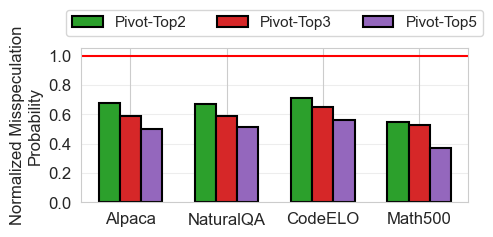

[skip] figure_pivot_normalized_misspeculation_probability: no Pivot-Top1 rows for Qwen3-32B+Qwen3-0.6B

[figure_pivot_normalized_misspeculation_probability] model_pair=Qwen3-32B+Qwen3-0.6B
policy=dynamic, expansion_pct=0.2, k=5, temp=None

method=Pivot-Top2
  dataset=Alpaca     pivot_misspec=0.265493 sd_misspec=0.322637 normalized_misspeculation=0.822886 vs_sd_reduction=0.177114 vs_sd_reduction_percent=17.71%
  dataset=NaturalQA  pivot_misspec=0.315437 sd_misspec=0.367146 normalized_misspeculation=0.859160 vs_sd_reduction=0.140840 vs_sd_reduction_percent=14.08%
  dataset=CodeELO    pivot_misspec=0.222733 sd_misspec=0.284925 normalized_misspeculation=0.781726 vs_sd_reduction=0.218274 vs_sd_reduction_percent=21.83%
  dataset=Math500    pivot_misspec=0.127096 sd_misspec=0.173729 normalized_misspeculation=0.731579 vs_sd_reduction=0.268421 vs_sd_reduction_percent=26.84%
  geomean_normalized_misspeculation=0.797411
  geomean_vs_sd_reduction=0.202589 geomean_vs_sd_reduction_percent=20.26%

me

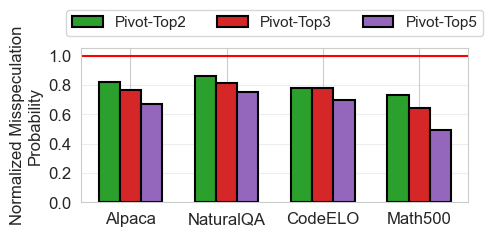

In [200]:
# =========================
# Pivot normalized misspeculation probability
# normalized to standard speculative decoding
# dynamic policy, expansion pct = 20%
# Shared colors with throughput figure
# =========================

PIVOT_MISSPEC_TOPKS = [1, 2, 3, 5]
PIVOT_MISSPEC_TOPK_LABELS = [f"Pivot-Top{k}" for k in PIVOT_MISSPEC_TOPKS]

PIVOT_MISSPEC_EXPANSION_PCT = 0.2
PIVOT_MISSPEC_POLICY = "dynamic"
PIVOT_MISSPEC_TEMP = None   # 예를 들면 0.0, 0.3, 0.7

SHARED_PIVOT_METHOD_COLORS = AR_NORM_METHOD_COLORS

# Do not call color_map(PIVOT_MISSPEC_TOPK_LABELS) here.
# Use the shared colormap so Pivot-Top{k} has the same color across figures.
PIVOT_MISSPEC_COLORS = SHARED_PIVOT_METHOD_COLORS


def _normalize_expansion_pct(series):
    vals = pd.to_numeric(series, errors="coerce")
    vals = vals.where(vals <= 1.0, vals / 100.0)
    return vals


def _filter_temp_optional(df, temp=PIVOT_MISSPEC_TEMP):
    if temp is None or "temperature" not in df.columns:
        return df.copy()

    out = df.copy()
    temp_vals = pd.to_numeric(out["temperature"], errors="coerce")
    return out[np.isclose(temp_vals, float(temp))].copy()


def _geomean(values, eps=1e-12):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    if len(values) == 0:
        return np.nan

    values = np.clip(values, eps, None)
    return float(np.exp(np.mean(np.log(values))))


def _pivot_rows_motivation(df):
    out = df.copy()

    out = out[out["method_pretty"] == "Pivot"].copy()

    if "speculative_length" in out.columns:
        out = out[out["speculative_length"] == SPECULATIVE_LENGTH].copy()

    if "pivot_expansion_policy" in out.columns:
        policy = out["pivot_expansion_policy"].astype(str).str.lower()
        out = out[policy.str.contains(PIVOT_MISSPEC_POLICY, na=False)].copy()

    if "pivot_expansion_pct" in out.columns:
        pct = _normalize_expansion_pct(out["pivot_expansion_pct"])
        out = out[np.isclose(pct, PIVOT_MISSPEC_EXPANSION_PCT, atol=1e-6)].copy()

    out = _filter_temp_optional(out)

    return out


def _sd_rows_motivation(df):
    out = df.copy()

    out = out[out["method_pretty"] == "SD"].copy()

    if "speculative_length" in out.columns:
        out = out[out["speculative_length"] == SPECULATIVE_LENGTH].copy()

    out = _filter_temp_optional(out)

    return out


def plot_figure_pivot_normalized_misspeculation_probability():
    fig_name = "figure_pivot_normalized_misspeculation_probability"

    required_cols = [
        "model_pair",
        "dataset",
        "method_pretty",
        "speculative_length",
        "misspeculation_probability",
        "pivot_expansion_policy",
        "pivot_topk",
        "pivot_expansion_pct",
    ]

    if not nonempty(motivation_df, required_cols, fig_name):
        return

    df_all = motivation_df.copy()

    pivot_all = _pivot_rows_motivation(df_all)
    sd_all = _sd_rows_motivation(df_all)

    if pivot_all.empty:
        print(
            f"[skip] {fig_name}: no Pivot rows after "
            f"policy={PIVOT_MISSPEC_POLICY}, "
            f"expansion_pct={PIVOT_MISSPEC_EXPANSION_PCT}, "
            f"k={SPECULATIVE_LENGTH}, temp={PIVOT_MISSPEC_TEMP}"
        )
        return

    if sd_all.empty:
        print(f"[skip] {fig_name}: no SD rows")
        return

    valid_model_pairs = sorted(
        set(pivot_all["model_pair"].dropna().unique()).intersection(
            set(sd_all["model_pair"].dropna().unique())
        )
    )

    if not valid_model_pairs:
        print(f"[skip] {fig_name}: no model_pair with both SD and Pivot rows")
        return

    for model_pair in valid_model_pairs:
        sd_df = _sd_rows_motivation(
            df_all[df_all["model_pair"] == model_pair].copy()
        )

        pivot_df_all = _pivot_rows_motivation(
            df_all[df_all["model_pair"] == model_pair].copy()
        )

        if sd_df.empty:
            print(f"[skip] {fig_name}: no SD rows for {model_pair}")
            continue

        if pivot_df_all.empty:
            print(f"[skip] {fig_name}: no Pivot rows for {model_pair}")
            continue

        sd_agg = (
            sd_df.dropna(subset=["misspeculation_probability"])
            .groupby("dataset", as_index=False)["misspeculation_probability"]
            .mean()
            .rename(columns={"misspeculation_probability": "sd_misspec"})
        )

        rows = []

        for topk in PIVOT_MISSPEC_TOPKS:
            pivot_df = pivot_df_all[
                pd.to_numeric(pivot_df_all["pivot_topk"], errors="coerce").eq(topk)
            ].copy()

            if pivot_df.empty:
                print(f"[skip] {fig_name}: no Pivot-Top{topk} rows for {model_pair}")
                continue

            pivot_agg = (
                pivot_df.dropna(subset=["misspeculation_probability"])
                .groupby("dataset", as_index=False)["misspeculation_probability"]
                .mean()
                .rename(columns={"misspeculation_probability": "pivot_misspec"})
            )

            merged = pivot_agg.merge(sd_agg, on="dataset", how="inner")

            if merged.empty:
                print(f"[skip] {fig_name}: no merged rows for Pivot-Top{topk}, {model_pair}")
                continue

            merged["method_label"] = f"Pivot-Top{topk}"
            merged["normalized_misspec"] = (
                merged["pivot_misspec"] / merged["sd_misspec"]
            )

            rows.append(merged)

        if not rows:
            print(f"[skip] {fig_name}: no rows to plot for {model_pair}")
            continue

        plot_df = pd.concat(rows, ignore_index=True)

        datasets = [d for d in DATASET_ORDER if d in set(plot_df["dataset"])]
        datasets += [
            d for d in sorted_datasets(plot_df["dataset"].unique())
            if d not in datasets
        ]

        methods = [
            m for m in PIVOT_MISSPEC_TOPK_LABELS
            if m in set(plot_df["method_label"])
        ]

        x = np.arange(len(datasets))
        width = 0.18 if len(methods) >= 4 else 0.22

        fig, ax = plt.subplots(figsize=(5, 2))

        all_vals = []

        print("\n" + "=" * 90)
        print(f"[{fig_name}] model_pair={model_pair}")
        print(
            f"policy={PIVOT_MISSPEC_POLICY}, "
            f"expansion_pct={PIVOT_MISSPEC_EXPANSION_PCT}, "
            f"k={SPECULATIVE_LENGTH}, "
            f"temp={PIVOT_MISSPEC_TEMP}"
        )
        print("=" * 90)

        for i, method in enumerate(methods):
            vals = []
            raw_pivot_vals = []
            raw_sd_vals = []

            for dataset in datasets:
                sub = plot_df[
                    (plot_df["dataset"] == dataset)
                    & (plot_df["method_label"] == method)
                ]

                if sub.empty:
                    vals.append(np.nan)
                    raw_pivot_vals.append(np.nan)
                    raw_sd_vals.append(np.nan)
                else:
                    vals.append(float(sub["normalized_misspec"].iloc[0]))
                    raw_pivot_vals.append(float(sub["pivot_misspec"].iloc[0]))
                    raw_sd_vals.append(float(sub["sd_misspec"].iloc[0]))

            all_vals.extend([v for v in vals if np.isfinite(v)])

            print(f"\nmethod={method}")
            for dataset, y, pivot_y, sd_y in zip(datasets, vals, raw_pivot_vals, raw_sd_vals):
                reduction = 1.0 - y if np.isfinite(y) else np.nan
                reduction_percent = reduction * 100.0 if np.isfinite(reduction) else np.nan

                print(
                    f"  dataset={dataset:<10} "
                    f"pivot_misspec={pivot_y:.6f} "
                    f"sd_misspec={sd_y:.6f} "
                    f"normalized_misspeculation={y:.6f} "
                    f"vs_sd_reduction={reduction:.6f} "
                    f"vs_sd_reduction_percent={reduction_percent:.2f}%"
                )

            gmean = _geomean(vals)
            gmean_reduction = 1.0 - gmean
            gmean_reduction_percent = gmean_reduction * 100.0

            print(f"  geomean_normalized_misspeculation={gmean:.6f}")
            print(
                f"  geomean_vs_sd_reduction={gmean_reduction:.6f} "
                f"geomean_vs_sd_reduction_percent={gmean_reduction_percent:.2f}%"
            )

            offset = (i - (len(methods) - 1) / 2) * width

            ax.bar(
                x + offset,
                vals,
                width=width,
                label=method,
                color=PIVOT_MISSPEC_COLORS[method],
                edgecolor="black",
                linewidth=1.5,
            )

        ymax = (
            1.05
            if len(all_vals) == 0
            else max(1.05, np.ceil(max(all_vals) / 0.2) * 0.2)
        )
        ymax = min(ymax, 2.0)

        ax.set_xticks(x)
        ax.set_xticklabels(datasets)
        ax.set_ylabel("Normalized Misspeculation\nProbability")
        ax.set_ylim(0.0, ymax)
        ax.set_yticks(np.arange(0.0, 1.2, 0.2))
        ax.grid(True, axis="y", alpha=0.35)
    
        ax.axhline(
            y=1.0,
            color="red",
            linestyle="-",
            linewidth=1.5,
        )

        ax.legend(
            loc="upper center",
            bbox_to_anchor=(0.5, 1.3),
            ncol=len(methods),
            fancybox=True,
            shadow=False,
            fontsize=11,
            frameon=True,
        )

        temp_suffix = (
            ""
            if PIVOT_MISSPEC_TEMP is None
            else f"_temp{safe_temp_label(PIVOT_MISSPEC_TEMP)}"
        )
        exp_suffix = f"_exp{str(PIVOT_MISSPEC_EXPANSION_PCT).replace('.', 'p')}"
        policy_suffix = f"_{PIVOT_MISSPEC_POLICY}"

        save_fig(
            fig,
            "./plots_results/pivot_results",
            f"{model_pair}_{fig_name}{policy_suffix}{temp_suffix}{exp_suffix}_k{SPECULATIVE_LENGTH}",
        )

        plt.show()


plot_figure_pivot_normalized_misspeculation_probability()

[skip] execution breakdown: no Pivot-Top1 rows for Llama-3.3-70B-Instruct

[figure_execution_breakdown_normalized_to_sd_geomean_only] target_model=Llama-3.3-70B-Instruct
policy=dynamic, expansion_pct=0.2, k=5, temp=None
SD execution geomean denominator = 39.592922

[Geomean normalized breakdown]
  method=SD         exec_geomean=39.592922 normalized_exec=1.000000 draft=0.331492 verification=0.589221 expansion=0.000000 others=0.074614 stacked_total=0.995326
  method=Pivot-Top2 exec_geomean=41.389911 normalized_exec=1.045387 draft=0.320392 verification=0.579339 expansion=0.041941 others=0.099525 stacked_total=1.041197
  method=Pivot-Top3 exec_geomean=42.740810 normalized_exec=1.079506 draft=0.318071 verification=0.598663 expansion=0.060208 others=0.098910 stacked_total=1.075852
  method=Pivot-Top5 exec_geomean=44.358491 normalized_exec=1.120364 draft=0.319466 verification=0.625062 expansion=0.070659 others=0.101897 stacked_total=1.117083
saved: plots_results/pivot_results/Llama-3.3-70B-In

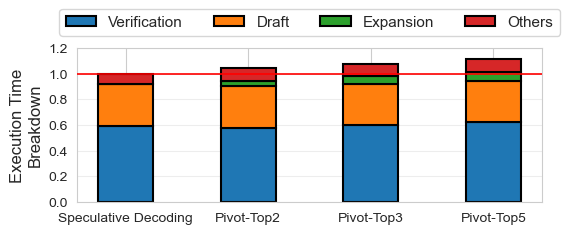

[skip] execution breakdown: no Pivot-Top1 rows for Qwen3-32B

[figure_execution_breakdown_normalized_to_sd_geomean_only] target_model=Qwen3-32B
policy=dynamic, expansion_pct=0.2, k=5, temp=None
SD execution geomean denominator = 50.537985

[Geomean normalized breakdown]
  method=SD         exec_geomean=50.537985 normalized_exec=1.000000 draft=0.418399 verification=0.510444 expansion=0.000000 others=0.060528 stacked_total=0.989371
  method=Pivot-Top2 exec_geomean=50.855393 normalized_exec=1.006281 draft=0.391369 verification=0.490263 expansion=0.029434 others=0.086279 stacked_total=0.997345
  method=Pivot-Top3 exec_geomean=53.405229 normalized_exec=1.056734 draft=0.395075 verification=0.511647 expansion=0.055385 others=0.085836 stacked_total=1.047943
  method=Pivot-Top5 exec_geomean=56.355365 normalized_exec=1.115109 draft=0.394471 verification=0.552918 expansion=0.071837 others=0.086232 stacked_total=1.105458
saved: plots_results/pivot_results/Qwen3-32B_figure_execution_breakdown_norma

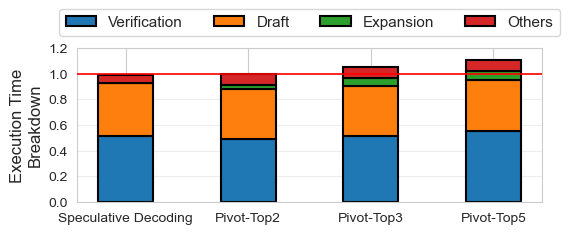

In [201]:
# =========================
# Normalized Execution Time Breakdown
# Normalize every component by SD execution time
# Panels: Alpaca, NaturalQA, CodeELO, Math500, Geomean
# X-axis: SD, Pivot-Top1, Pivot-Top2, Pivot-Top3, Pivot-Top5
# Legend: Draft, Verification, Expansion, Others
# =========================

EXEC_BREAKDOWN_TOPKS = [1, 2, 3, 5]
EXEC_BREAKDOWN_METHODS = ["SD"] + [f"Pivot-Top{k}" for k in EXEC_BREAKDOWN_TOPKS]

EXEC_BREAKDOWN_DATASETS = ["Alpaca", "NaturalQA", "CodeELO", "Math500"]

EXEC_BREAKDOWN_POLICY = "dynamic"     # 필요하면 "static"으로 변경
EXEC_BREAKDOWN_EXPANSION_PCT = 0.2    # 필요하면 변경
EXEC_BREAKDOWN_TEMP = None            # 예: 0.0, 0.3, 0.7

EXEC_BREAKDOWN_COMPONENTS = ["Verification", "Draft", "Expansion", "Others"]

EXEC_BREAKDOWN_COLORS = {
    "Verification": palette[0],
    "Draft": palette[1],
    "Expansion": palette[2],
    "Others": palette[3],
}

def _normalize_expansion_pct(series):
    vals = pd.to_numeric(series, errors="coerce")
    vals = vals.where(vals <= 1.0, vals / 100.0)
    return vals


def _filter_temp_optional_exec(df, temp=EXEC_BREAKDOWN_TEMP):
    if temp is None:
        return df.copy()

    if "temperature" not in df.columns:
        return df.copy()

    out = df.copy()
    temp_vals = pd.to_numeric(out["temperature"], errors="coerce")
    return out[np.isclose(temp_vals, float(temp))].copy()


def _geomean(values, eps=1e-12):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    if len(values) == 0:
        return np.nan

    values = np.clip(values, eps, None)
    return float(np.exp(np.mean(np.log(values))))


def _get_expansion_time_from_row(row):
    if str(row.get("method_pretty", "")) == "SD":
        return 0.0

    for col in ["pivot_expansion_time_s", "pivot_full_expansion_overhead_time_s"]:
        if col in row and pd.notna(row[col]):
            return float(row[col])

    return 0.0


def _prepare_exec_breakdown_df(df):
    out = df.copy()

    if "execution_wall_time_s" not in out.columns:
        raise ValueError("execution_wall_time_s column is required")

    out["execution_time"] = pd.to_numeric(out["execution_wall_time_s"], errors="coerce")
    out["draft_time"] = pd.to_numeric(out.get("draft_time_s", 0.0), errors="coerce").fillna(0.0)
    out["verification_time"] = pd.to_numeric(out.get("verification_time_s", 0.0), errors="coerce").fillna(0.0)
    out["expansion_time"] = out.apply(_get_expansion_time_from_row, axis=1)

    out["others_time"] = (
        out["execution_time"]
        - out["draft_time"]
        - out["verification_time"]
        - out["expansion_time"]
    )

    out["others_time"] = out["others_time"].clip(lower=0.0)

    return out


def _filter_sd_rows_exec(df):
    out = df.copy()
    out = out[out["method_pretty"] == "SD"].copy()

    if "speculative_length" in out.columns:
        out = out[out["speculative_length"] == SPECULATIVE_LENGTH].copy()

    out = _filter_temp_optional_exec(out)

    return out


def _filter_pivot_rows_exec(df):
    out = df.copy()
    out = out[out["method_pretty"] == "Pivot"].copy()

    if "speculative_length" in out.columns:
        out = out[out["speculative_length"] == SPECULATIVE_LENGTH].copy()

    if "pivot_expansion_policy" in out.columns:
        policy = out["pivot_expansion_policy"].astype(str).str.lower()
        out = out[policy.str.contains(EXEC_BREAKDOWN_POLICY, na=False)].copy()

    if "pivot_expansion_pct" in out.columns:
        pct = _normalize_expansion_pct(out["pivot_expansion_pct"])
        out = out[np.isclose(pct, EXEC_BREAKDOWN_EXPANSION_PCT, atol=1e-6)].copy()

    out = _filter_temp_optional_exec(out)

    return out


def _build_exec_breakdown_rows_for_target(target_model):
    df = results_df[results_df["target_model"].astype(str) == str(target_model)].copy()
    if df.empty:
        return pd.DataFrame()

    df = _prepare_exec_breakdown_df(df)

    sd_df = _filter_sd_rows_exec(df)
    pivot_df = _filter_pivot_rows_exec(df)

    if sd_df.empty:
        print(f"[skip] execution breakdown: no SD rows for {target_model}")
        return pd.DataFrame()

    rows = []

    # SD
    sd_agg = (
        sd_df.groupby("dataset", as_index=False)[
            ["execution_time", "draft_time", "verification_time", "expansion_time", "others_time"]
        ]
        .mean()
    )
    sd_agg["method_label"] = "SD"
    rows.append(sd_agg)

    # Pivot topk
    for topk in EXEC_BREAKDOWN_TOPKS:
        sub = pivot_df[
            pd.to_numeric(pivot_df["pivot_topk"], errors="coerce").eq(topk)
        ].copy()

        if sub.empty:
            print(f"[skip] execution breakdown: no Pivot-Top{topk} rows for {target_model}")
            continue

        sub_agg = (
            sub.groupby("dataset", as_index=False)[
                ["execution_time", "draft_time", "verification_time", "expansion_time", "others_time"]
            ]
            .mean()
        )
        sub_agg["method_label"] = f"Pivot-Top{topk}"
        rows.append(sub_agg)

    if not rows:
        return pd.DataFrame()

    out = pd.concat(rows, ignore_index=True)
    return out


def plot_figure_execution_breakdown_normalized_to_sd():
    fig_name = "figure_execution_breakdown_normalized_to_sd_geomean_only"

    required_cols = [
        "target_model",
        "dataset",
        "method_pretty",
        "execution_wall_time_s",
        "draft_time_s",
        "verification_time_s",
    ]

    if not nonempty(results_df, required_cols, fig_name):
        return

    target_models_local = sorted_target_models(results_df)

    xtick_label_map = {
        "SD": "Speculative Decoding",
        "Pivot-Top1": "Pivot-Top1",
        "Pivot-Top2": "Pivot-Top2",
        "Pivot-Top3": "Pivot-Top3",
        "Pivot-Top5": "Pivot-Top5",
    }

    for target_model in target_models_local:
        plot_df = _build_exec_breakdown_rows_for_target(target_model)

        if plot_df.empty:
            print(f"[skip] {fig_name}: empty plot_df for {target_model}")
            continue

        datasets = [d for d in EXEC_BREAKDOWN_DATASETS if d in set(plot_df["dataset"])]
        if not datasets:
            print(f"[skip] {fig_name}: no requested datasets for {target_model}")
            continue

        methods = [m for m in EXEC_BREAKDOWN_METHODS if m in set(plot_df["method_label"])]

        sd_exec_by_dataset = {}
        for dataset in datasets:
            sub_sd = plot_df[
                (plot_df["dataset"] == dataset)
                & (plot_df["method_label"] == "SD")
            ]

            if sub_sd.empty:
                sd_exec_by_dataset[dataset] = np.nan
            else:
                sd_exec_by_dataset[dataset] = float(sub_sd["execution_time"].iloc[0])

        sd_exec_gmean = _geomean([sd_exec_by_dataset[d] for d in datasets])

        if not np.isfinite(sd_exec_gmean) or sd_exec_gmean <= 0:
            print(f"[skip] {fig_name}: invalid SD geomean denominator for {target_model}")
            continue

        print("\n" + "=" * 110)
        print(f"[{fig_name}] target_model={target_model}")
        print(
            f"policy={EXEC_BREAKDOWN_POLICY}, "
            f"expansion_pct={EXEC_BREAKDOWN_EXPANSION_PCT}, "
            f"k={SPECULATIVE_LENGTH}, "
            f"temp={EXEC_BREAKDOWN_TEMP}"
        )
        print(f"SD execution geomean denominator = {sd_exec_gmean:.6f}")
        print("=" * 110)

        fig, ax = plt.subplots(figsize=(6, 2))

        x = np.arange(len(methods))
        bottom = np.zeros(len(methods), dtype=float)
        all_stack_vals = []

        for comp in EXEC_BREAKDOWN_COMPONENTS:
            comp_vals = []

            for method in methods:
                sub_method = plot_df[plot_df["method_label"] == method].copy()

                vals = []
                for dataset in datasets:
                    sub = sub_method[sub_method["dataset"] == dataset]
                    if sub.empty:
                        continue

                    if comp == "Draft":
                        vals.append(float(sub["draft_time"].iloc[0]))
                    elif comp == "Verification":
                        vals.append(float(sub["verification_time"].iloc[0]))
                    elif comp == "Expansion":
                        vals.append(float(sub["expansion_time"].iloc[0]))
                    elif comp == "Others":
                        vals.append(float(sub["others_time"].iloc[0]))

                if comp == "Expansion" and method == "SD":
                    comp_g = 0.0
                else:
                    comp_g = _geomean(vals)

                comp_vals.append(
                    comp_g / sd_exec_gmean
                    if np.isfinite(comp_g)
                    else np.nan
                )

            comp_vals = np.asarray(comp_vals, dtype=float)

            ax.bar(
                x,
                comp_vals,
                bottom=bottom,
                width=0.45,
                label=comp,
                color=EXEC_BREAKDOWN_COLORS[comp],
                edgecolor="black",
                linewidth=1.5,
            )

            bottom = bottom + np.nan_to_num(comp_vals, nan=0.0)
            all_stack_vals.extend([v for v in bottom if np.isfinite(v)])

        print("\n[Geomean normalized breakdown]")
        for method_idx, method in enumerate(methods):
            sub_method = plot_df[plot_df["method_label"] == method].copy()

            exec_vals = []
            draft_vals = []
            verif_vals = []
            exp_vals = []
            other_vals = []

            for dataset in datasets:
                sub = sub_method[sub_method["dataset"] == dataset]
                if sub.empty:
                    continue

                exec_vals.append(float(sub["execution_time"].iloc[0]))
                draft_vals.append(float(sub["draft_time"].iloc[0]))
                verif_vals.append(float(sub["verification_time"].iloc[0]))
                exp_vals.append(float(sub["expansion_time"].iloc[0]))
                other_vals.append(float(sub["others_time"].iloc[0]))

            exec_g = _geomean(exec_vals)
            draft_g = _geomean(draft_vals)
            verif_g = _geomean(verif_vals)
            exp_g = 0.0 if method == "SD" else _geomean(exp_vals)
            other_g = _geomean(other_vals)

            norm_exec = exec_g / sd_exec_gmean
            norm_draft = draft_g / sd_exec_gmean
            norm_verif = verif_g / sd_exec_gmean
            norm_exp = exp_g / sd_exec_gmean
            norm_other = other_g / sd_exec_gmean
            norm_stacked_total = norm_draft + norm_verif + norm_exp + norm_other

            print(
                f"  method={method:<10} "
                f"exec_geomean={exec_g:.6f} "
                f"normalized_exec={norm_exec:.6f} "
                f"draft={norm_draft:.6f} "
                f"verification={norm_verif:.6f} "
                f"expansion={norm_exp:.6f} "
                f"others={norm_other:.6f} "
                f"stacked_total={norm_stacked_total:.6f}"
            )

        ymax = (
            1.1
            if len(all_stack_vals) == 0
            else max(1.1, np.ceil(max(all_stack_vals) / 0.2) * 0.2)
        )
        ymax = min(ymax, 3.0)

        ax.set_xticks(x)
        ax.set_xticklabels(
            [xtick_label_map.get(m, m) for m in methods],
            rotation=0,
            ha="center",
        )

        ax.set_ylabel("Execution Time\nBreakdown", fontsize=12)
        ax.set_ylim(0.0, ymax)
        ax.set_yticks(np.arange(0.0, ymax + 1e-9, 0.2))
        ax.tick_params(axis="both", which="major", labelsize=10)
        ax.grid(True, axis="y", alpha=0.35)

        ax.axhline(
            y=1.0,
            color="red",
            linestyle="-",
            linewidth=1.2,
            zorder=5,
        )

        handles, labels = ax.get_legend_handles_labels()
        by_label = dict(zip(labels, handles))
        ax.legend(
            by_label.values(),
            by_label.keys(),
            loc="upper center",
            bbox_to_anchor=(0.5, 1.3),
            ncol=4,
            fancybox=True,
            shadow=False,
            fontsize=11,
            frameon=True,
        )

        temp_suffix = (
            ""
            if EXEC_BREAKDOWN_TEMP is None
            else f"_temp{safe_temp_label(EXEC_BREAKDOWN_TEMP)}"
        )
        pct_suffix = f"_exp{str(EXEC_BREAKDOWN_EXPANSION_PCT).replace('.', 'p')}"
        policy_suffix = f"_{EXEC_BREAKDOWN_POLICY}"

        save_fig(
            fig,
            "./plots_results/pivot_results",
            f"{target_model}_{fig_name}{policy_suffix}{temp_suffix}{pct_suffix}_k{SPECULATIVE_LENGTH}",
        )

        plt.show()


plot_figure_execution_breakdown_normalized_to_sd()




[figure_geomean_normalized_batch_time] target_model=Llama-3.3-70B-Instruct
policy=dynamic, expansion_pct=0.2, k=5, temp=None
SD draft geomean denominator        = 0.012476
SD verification geomean denominator = 0.022175
method=Pivot-Top2  pivot_draft_geomean=0.012598  pivot_verification_geomean=0.022779  normalized_draft=1.009774  normalized_verification=1.027235
method=Pivot-Top3  pivot_draft_geomean=0.012637  pivot_verification_geomean=0.023784  normalized_draft=1.012901  normalized_verification=1.072554
method=Pivot-Top5  pivot_draft_geomean=0.012967  pivot_verification_geomean=0.025372  normalized_draft=1.039408  normalized_verification=1.144140
saved: plots_results/pivot_results/Llama-3.3-70B-Instruct_figure_geomean_normalized_batch_time_dynamic_exp0p2_k5.pdf
saved: plots_results/pivot_results/Llama-3.3-70B-Instruct_figure_geomean_normalized_batch_time_dynamic_exp0p2_k5.png


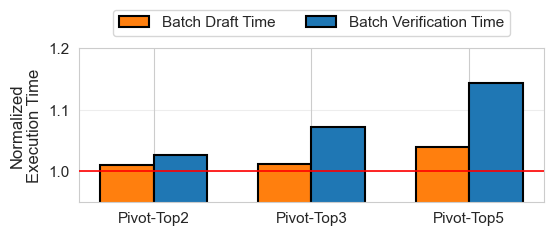


[figure_geomean_normalized_batch_time] target_model=Qwen3-32B
policy=dynamic, expansion_pct=0.2, k=5, temp=None
SD draft geomean denominator        = 0.015961
SD verification geomean denominator = 0.019473
method=Pivot-Top2  pivot_draft_geomean=0.015928  pivot_verification_geomean=0.019953  normalized_draft=0.997894  normalized_verification=1.024637
method=Pivot-Top3  pivot_draft_geomean=0.015950  pivot_verification_geomean=0.020657  normalized_draft=0.999305  normalized_verification=1.060793
method=Pivot-Top5  pivot_draft_geomean=0.016307  pivot_verification_geomean=0.022858  normalized_draft=1.021678  normalized_verification=1.173822
saved: plots_results/pivot_results/Qwen3-32B_figure_geomean_normalized_batch_time_dynamic_exp0p2_k5.pdf
saved: plots_results/pivot_results/Qwen3-32B_figure_geomean_normalized_batch_time_dynamic_exp0p2_k5.png


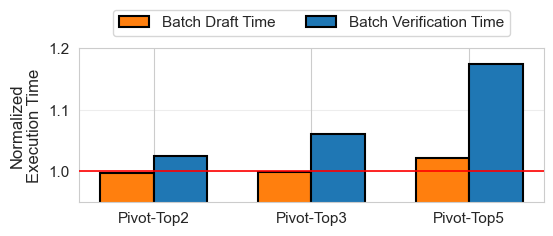

In [202]:
# =========================
# Geomean normalized batch time
# Side-by-side bars, not stacked
# Legend: Batch Draft Time, Batch Verification Time
# X-axis: Pivot-Top2, Pivot-Top3, Pivot-Top5
# Each component is normalized to SD geomean of the same component
# =========================

PIVOT_BATCH_TIME_TOPKS = [2, 3, 5]
PIVOT_BATCH_TIME_METHODS = [f"Pivot-Top{k}" for k in PIVOT_BATCH_TIME_TOPKS]
PIVOT_BATCH_TIME_DATASETS = ["Alpaca", "NaturalQA", "CodeELO", "Math500"]

PIVOT_BATCH_TIME_POLICY = "dynamic"      # 필요하면 "static"으로 변경
PIVOT_BATCH_TIME_EXPANSION_PCT = 0.2     # 필요하면 변경
PIVOT_BATCH_TIME_TEMP = None             # 예: 0.0, 0.3, 0.7

PIVOT_BATCH_TIME_COLORS = {
    "Batch Verification Time": palette[0],
    "Batch Draft Time": palette[1],
    
}


def _normalize_expansion_pct(series):
    vals = pd.to_numeric(series, errors="coerce")
    vals = vals.where(vals <= 1.0, vals / 100.0)
    return vals


def _filter_temp_optional_batch_time(df, temp=PIVOT_BATCH_TIME_TEMP):
    if temp is None:
        return df.copy()

    if "temperature" not in df.columns:
        return df.copy()

    out = df.copy()
    temp_vals = pd.to_numeric(out["temperature"], errors="coerce")
    return out[np.isclose(temp_vals, float(temp))].copy()


def _geomean(values, eps=1e-12):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    if len(values) == 0:
        return np.nan

    values = np.clip(values, eps, None)
    return float(np.exp(np.mean(np.log(values))))


def _filter_sd_rows_batch_time(df):
    out = df.copy()
    out = out[out["method_pretty"] == "SD"].copy()

    if "speculative_length" in out.columns:
        out = out[out["speculative_length"] == SPECULATIVE_LENGTH].copy()

    out = _filter_temp_optional_batch_time(out)
    return out


def _filter_pivot_rows_batch_time(df):
    out = df.copy()
    out = out[out["method_pretty"] == "Pivot"].copy()

    if "speculative_length" in out.columns:
        out = out[out["speculative_length"] == SPECULATIVE_LENGTH].copy()

    if "pivot_expansion_policy" in out.columns:
        policy = out["pivot_expansion_policy"].astype(str).str.lower()
        out = out[policy.str.contains(PIVOT_BATCH_TIME_POLICY, na=False)].copy()

    if "pivot_expansion_pct" in out.columns:
        pct = _normalize_expansion_pct(out["pivot_expansion_pct"])
        out = out[np.isclose(pct, PIVOT_BATCH_TIME_EXPANSION_PCT, atol=1e-6)].copy()

    out = _filter_temp_optional_batch_time(out)
    return out


def plot_figure_geomean_normalized_batch_time():
    fig_name = "figure_geomean_normalized_batch_time"

    required_cols = [
        "target_model",
        "dataset",
        "method_pretty",
        "avg_draft_time_per_batch",
        "avg_target_verification_time_per_batch",
    ]

    if not nonempty(results_df, required_cols, fig_name):
        return

    target_models_local = sorted_target_models(results_df)

    xtick_label_map = {
        "Pivot-Top2": "Pivot-Top2",
        "Pivot-Top3": "Pivot-Top3",
        "Pivot-Top5": "Pivot-Top5",
    }

    for target_model in target_models_local:
        df = results_df[results_df["target_model"].astype(str) == str(target_model)].copy()

        if df.empty:
            print(f"[skip] {fig_name}: no rows for {target_model}")
            continue

        sd_df = _filter_sd_rows_batch_time(df)
        pivot_df = _filter_pivot_rows_batch_time(df)

        if sd_df.empty:
            print(f"[skip] {fig_name}: no SD rows for {target_model}")
            continue

        if pivot_df.empty:
            print(
                f"[skip] {fig_name}: no Pivot rows for {target_model}, "
                f"policy={PIVOT_BATCH_TIME_POLICY}, "
                f"expansion_pct={PIVOT_BATCH_TIME_EXPANSION_PCT}, "
                f"k={SPECULATIVE_LENGTH}, temp={PIVOT_BATCH_TIME_TEMP}"
            )
            continue

        datasets = [d for d in PIVOT_BATCH_TIME_DATASETS if d in set(df["dataset"])]
        if not datasets:
            print(f"[skip] {fig_name}: no requested datasets for {target_model}")
            continue

        # SD denominators
        sd_draft_vals = []
        sd_verif_vals = []

        for dataset in datasets:
            sub = sd_df[sd_df["dataset"] == dataset].copy()
            if sub.empty:
                continue

            draft_val = pd.to_numeric(sub["avg_draft_time_per_batch"], errors="coerce").dropna()
            verif_val = pd.to_numeric(sub["avg_target_verification_time_per_batch"], errors="coerce").dropna()

            if len(draft_val) > 0:
                sd_draft_vals.append(float(draft_val.mean()))
            if len(verif_val) > 0:
                sd_verif_vals.append(float(verif_val.mean()))

        sd_draft_gmean = _geomean(sd_draft_vals)
        sd_verif_gmean = _geomean(sd_verif_vals)

        if not np.isfinite(sd_draft_gmean) or sd_draft_gmean <= 0:
            print(f"[skip] {fig_name}: invalid SD draft geomean for {target_model}")
            continue

        if not np.isfinite(sd_verif_gmean) or sd_verif_gmean <= 0:
            print(f"[skip] {fig_name}: invalid SD verification geomean for {target_model}")
            continue

        print("\n" + "=" * 100)
        print(f"[{fig_name}] target_model={target_model}")
        print(
            f"policy={PIVOT_BATCH_TIME_POLICY}, "
            f"expansion_pct={PIVOT_BATCH_TIME_EXPANSION_PCT}, "
            f"k={SPECULATIVE_LENGTH}, "
            f"temp={PIVOT_BATCH_TIME_TEMP}"
        )
        print(f"SD draft geomean denominator        = {sd_draft_gmean:.6f}")
        print(f"SD verification geomean denominator = {sd_verif_gmean:.6f}")
        print("=" * 100)

        rows = []

        for topk in PIVOT_BATCH_TIME_TOPKS:
            sub_topk = pivot_df[
                pd.to_numeric(pivot_df["pivot_topk"], errors="coerce").eq(topk)
            ].copy()

            if sub_topk.empty:
                print(f"[skip] {fig_name}: no Pivot-Top{topk} rows for {target_model}")
                continue

            pivot_draft_vals = []
            pivot_verif_vals = []

            for dataset in datasets:
                sub = sub_topk[sub_topk["dataset"] == dataset].copy()
                if sub.empty:
                    continue

                draft_val = pd.to_numeric(sub["avg_draft_time_per_batch"], errors="coerce").dropna()
                verif_val = pd.to_numeric(sub["avg_target_verification_time_per_batch"], errors="coerce").dropna()

                if len(draft_val) > 0:
                    pivot_draft_vals.append(float(draft_val.mean()))
                if len(verif_val) > 0:
                    pivot_verif_vals.append(float(verif_val.mean()))

            pivot_draft_gmean = _geomean(pivot_draft_vals)
            pivot_verif_gmean = _geomean(pivot_verif_vals)

            norm_draft = pivot_draft_gmean / sd_draft_gmean if np.isfinite(pivot_draft_gmean) else np.nan
            norm_verif = pivot_verif_gmean / sd_verif_gmean if np.isfinite(pivot_verif_gmean) else np.nan

            rows.append(
                {
                    "method_label": f"Pivot-Top{topk}",
                    "pivot_draft_gmean": pivot_draft_gmean,
                    "pivot_verif_gmean": pivot_verif_gmean,
                    "normalized_draft": norm_draft,
                    "normalized_verification": norm_verif,
                }
            )

            print(
                f"method=Pivot-Top{topk}  "
                f"pivot_draft_geomean={pivot_draft_gmean:.6f}  "
                f"pivot_verification_geomean={pivot_verif_gmean:.6f}  "
                f"normalized_draft={norm_draft:.6f}  "
                f"normalized_verification={norm_verif:.6f}"
            )

        plot_df = pd.DataFrame(rows)

        if plot_df.empty:
            print(f"[skip] {fig_name}: empty plot_df for {target_model}")
            continue

        methods = [m for m in PIVOT_BATCH_TIME_METHODS if m in set(plot_df["method_label"])]

        fig, ax = plt.subplots(figsize=(6, 2))

        x = np.arange(len(methods))
        width = 0.34

        draft_vals = []
        verif_vals = []

        for method in methods:
            sub = plot_df[plot_df["method_label"] == method]
            if sub.empty:
                draft_vals.append(np.nan)
                verif_vals.append(np.nan)
            else:
                draft_vals.append(float(sub["normalized_draft"].iloc[0]))
                verif_vals.append(float(sub["normalized_verification"].iloc[0]))

        draft_vals = np.asarray(draft_vals, dtype=float)
        verif_vals = np.asarray(verif_vals, dtype=float)

        ax.bar(
            x - width / 2,
            draft_vals,
            width=width,
            label="Batch Draft Time",
            color=PIVOT_BATCH_TIME_COLORS["Batch Draft Time"],
            edgecolor="black",
            linewidth=1.5,
        )

        ax.bar(
            x + width / 2,
            verif_vals,
            width=width,
            label="Batch Verification Time",
            color=PIVOT_BATCH_TIME_COLORS["Batch Verification Time"],
            edgecolor="black",
            linewidth=1.5,
        )

        all_vals = []
        all_vals.extend([v for v in draft_vals if np.isfinite(v)])
        all_vals.extend([v for v in verif_vals if np.isfinite(v)])

        ymax = (
            1.1
            if len(all_vals) == 0
            else max(1.1, np.ceil(max(all_vals) / 0.2) * 0.2)
        )
        ymax = min(ymax, 3.0)

        ax.set_xticks(x)
        ax.set_xticklabels(
            [xtick_label_map.get(m, m) for m in methods],
            rotation=0,
            ha="center",
        )
        ax.set_ylabel("Normalized\nExecution Time", fontsize=12)
        ax.set_ylim(0.95, ymax)
        ax.set_yticks(np.arange(1.0, ymax + 1e-9, 0.1))
        ax.tick_params(axis="both", which="major", labelsize=11)
        ax.grid(True, axis="y", alpha=0.35)

        ax.axhline(
            y=1.0,
            color="red",
            linestyle="-",
            linewidth=1.2,
            zorder=5,
        )

        handles, labels = ax.get_legend_handles_labels()
        by_label = dict(zip(labels, handles))
        ax.legend(
            by_label.values(),
            by_label.keys(),
            loc="upper center",
            bbox_to_anchor=(0.5, 1.30),
            ncol=2,
            fancybox=True,
            shadow=False,
            fontsize=11,
            frameon=True,
        )

        temp_suffix = (
            ""
            if PIVOT_BATCH_TIME_TEMP is None
            else f"_temp{safe_temp_label(PIVOT_BATCH_TIME_TEMP)}"
        )
        pct_suffix = f"_exp{str(PIVOT_BATCH_TIME_EXPANSION_PCT).replace('.', 'p')}"
        policy_suffix = f"_{PIVOT_BATCH_TIME_POLICY}"

        save_fig(
            fig,
            "./plots_results/pivot_results",
            f"{target_model}_{fig_name}{policy_suffix}{temp_suffix}{pct_suffix}_k{SPECULATIVE_LENGTH}",
        )

        plt.show()


plot_figure_geomean_normalized_batch_time()

[skip] figure_average_batch_size: no Pivot-Top1 rows for Llama-3.3-70B-Instruct
[skip] figure_average_batch_size: no Pivot-Top4 rows for Llama-3.3-70B-Instruct

[figure_average_batch_size] target_model=Llama-3.3-70B-Instruct
policy=dynamic, expansion_pct=0.2, k=5, temp=None
  method=Speculative Decoding   geomean_batch_size=14.933575
  method=Pivot-Top2             geomean_batch_size=17.660041
  method=Pivot-Top3             geomean_batch_size=20.300152
  method=Pivot-Top5             geomean_batch_size=25.864159
saved: plots_results/pivot_results/Llama-3.3-70B-Instruct_figure_average_batch_size_dynamic_exp0p2_k5.pdf
saved: plots_results/pivot_results/Llama-3.3-70B-Instruct_figure_average_batch_size_dynamic_exp0p2_k5.png


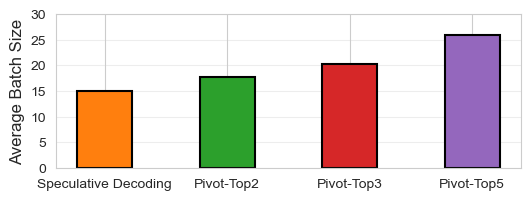

[skip] figure_average_batch_size: no Pivot-Top1 rows for Qwen3-32B
[skip] figure_average_batch_size: no Pivot-Top4 rows for Qwen3-32B

[figure_average_batch_size] target_model=Qwen3-32B
policy=dynamic, expansion_pct=0.2, k=5, temp=None
  method=Speculative Decoding   geomean_batch_size=14.954713
  method=Pivot-Top2             geomean_batch_size=17.857622
  method=Pivot-Top3             geomean_batch_size=20.137386
  method=Pivot-Top5             geomean_batch_size=25.092901
saved: plots_results/pivot_results/Qwen3-32B_figure_average_batch_size_dynamic_exp0p2_k5.pdf
saved: plots_results/pivot_results/Qwen3-32B_figure_average_batch_size_dynamic_exp0p2_k5.png


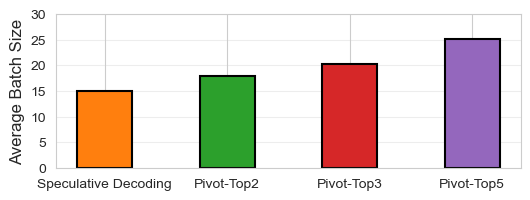

In [203]:
# =========================
# Average Batch Size
# SD: geomean(avg_decode_scheduled_batch_size)
# Pivot: geomean(avg_after_expansion_batch_size)
# X-axis: Speculative Decoding, Pivot-Top1 ... Pivot-Top5
# =========================

AVG_BATCH_SIZE_TOPKS = [1, 2, 3, 4, 5]
AVG_BATCH_SIZE_METHODS = ["Speculative Decoding"] + [f"Pivot-Top{k}" for k in AVG_BATCH_SIZE_TOPKS]
AVG_BATCH_SIZE_DATASETS = ["Alpaca", "NaturalQA", "CodeELO", "Math500"]

AVG_BATCH_SIZE_POLICY = "dynamic"      # 필요하면 "static"으로 변경
AVG_BATCH_SIZE_EXPANSION_PCT = 0.2     # 필요하면 변경
AVG_BATCH_SIZE_TEMP = None             # 예: 0.0, 0.3, 0.7


AVG_BATCH_SIZE_COLORS = color_map(AR_NORM_METHODS)


def _normalize_expansion_pct(series):
    vals = pd.to_numeric(series, errors="coerce")
    vals = vals.where(vals <= 1.0, vals / 100.0)
    return vals


def _filter_temp_optional_avg_batch(df, temp=AVG_BATCH_SIZE_TEMP):
    if temp is None:
        return df.copy()

    if "temperature" not in df.columns:
        return df.copy()

    out = df.copy()
    temp_vals = pd.to_numeric(out["temperature"], errors="coerce")
    return out[np.isclose(temp_vals, float(temp))].copy()


def _geomean(values, eps=1e-12):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    if len(values) == 0:
        return np.nan

    values = np.clip(values, eps, None)
    return float(np.exp(np.mean(np.log(values))))


def _filter_sd_rows_avg_batch(df):
    out = df.copy()
    out = out[out["method_pretty"] == "SD"].copy()

    if "speculative_length" in out.columns:
        out = out[out["speculative_length"] == SPECULATIVE_LENGTH].copy()

    out = _filter_temp_optional_avg_batch(out)
    return out


def _filter_pivot_rows_avg_batch(df):
    out = df.copy()
    out = out[out["method_pretty"] == "Pivot"].copy()

    if "speculative_length" in out.columns:
        out = out[out["speculative_length"] == SPECULATIVE_LENGTH].copy()

    if "pivot_expansion_policy" in out.columns:
        policy = out["pivot_expansion_policy"].astype(str).str.lower()
        out = out[policy.str.contains(AVG_BATCH_SIZE_POLICY, na=False)].copy()

    if "pivot_expansion_pct" in out.columns:
        pct = _normalize_expansion_pct(out["pivot_expansion_pct"])
        out = out[np.isclose(pct, AVG_BATCH_SIZE_EXPANSION_PCT, atol=1e-6)].copy()

    out = _filter_temp_optional_avg_batch(out)
    return out


def plot_figure_average_batch_size():
    fig_name = "figure_average_batch_size"

    required_cols = [
        "target_model",
        "dataset",
        "method_pretty",
        "avg_decode_scheduled_batch_size",
        "avg_after_expansion_batch_size",
    ]

    if not nonempty(results_df, required_cols, fig_name):
        return

    xtick_label_map = {
        "Speculative Decoding": "Speculative Decoding",
        "Pivot-Top1": "Pivot-Top1",
        "Pivot-Top2": "Pivot-Top2",
        "Pivot-Top3": "Pivot-Top3",
        "Pivot-Top4": "Pivot-Top4",
        "Pivot-Top5": "Pivot-Top5",
    }

    target_models_local = sorted_target_models(results_df)

    for target_model in target_models_local:
        df = results_df[results_df["target_model"].astype(str) == str(target_model)].copy()

        if df.empty:
            print(f"[skip] {fig_name}: no rows for {target_model}")
            continue

        sd_df = _filter_sd_rows_avg_batch(df)
        pivot_df = _filter_pivot_rows_avg_batch(df)

        if sd_df.empty:
            print(f"[skip] {fig_name}: no SD rows for {target_model}")
            continue

        if pivot_df.empty:
            print(
                f"[skip] {fig_name}: no Pivot rows for {target_model}, "
                f"policy={AVG_BATCH_SIZE_POLICY}, "
                f"expansion_pct={AVG_BATCH_SIZE_EXPANSION_PCT}, "
                f"k={SPECULATIVE_LENGTH}, temp={AVG_BATCH_SIZE_TEMP}"
            )
            continue

        datasets = [d for d in AVG_BATCH_SIZE_DATASETS if d in set(df["dataset"])]
        if not datasets:
            print(f"[skip] {fig_name}: no requested datasets for {target_model}")
            continue

        rows = []

        # Speculative Decoding
        sd_vals = []
        for dataset in datasets:
            sub = sd_df[sd_df["dataset"] == dataset].copy()
            if sub.empty:
                continue

            vals = pd.to_numeric(sub["avg_decode_scheduled_batch_size"], errors="coerce").dropna()
            if len(vals) > 0:
                sd_vals.append(float(vals.mean()))

        sd_gmean = _geomean(sd_vals)
        rows.append(
            {
                "method_label": "Speculative Decoding",
                "geomean_batch_size": sd_gmean,
            }
        )

        # Pivot-Top1 ... Pivot-Top5
        for topk in AVG_BATCH_SIZE_TOPKS:
            sub_topk = pivot_df[
                pd.to_numeric(pivot_df["pivot_topk"], errors="coerce").eq(topk)
            ].copy()

            if sub_topk.empty:
                print(f"[skip] {fig_name}: no Pivot-Top{topk} rows for {target_model}")
                continue

            pivot_vals = []
            for dataset in datasets:
                sub = sub_topk[sub_topk["dataset"] == dataset].copy()
                if sub.empty:
                    continue

                vals = pd.to_numeric(sub["avg_after_expansion_batch_size"], errors="coerce").dropna()
                if len(vals) > 0:
                    pivot_vals.append(float(vals.mean()))

            pivot_gmean = _geomean(pivot_vals)
            rows.append(
                {
                    "method_label": f"Pivot-Top{topk}",
                    "geomean_batch_size": pivot_gmean,
                }
            )

        plot_df = pd.DataFrame(rows)

        if plot_df.empty:
            print(f"[skip] {fig_name}: empty plot_df for {target_model}")
            continue

        methods = [m for m in AVG_BATCH_SIZE_METHODS if m in set(plot_df["method_label"])]

        print("\n" + "=" * 100)
        print(f"[{fig_name}] target_model={target_model}")
        print(
            f"policy={AVG_BATCH_SIZE_POLICY}, "
            f"expansion_pct={AVG_BATCH_SIZE_EXPANSION_PCT}, "
            f"k={SPECULATIVE_LENGTH}, "
            f"temp={AVG_BATCH_SIZE_TEMP}"
        )
        print("=" * 100)

        values = []
        for method in methods:
            sub = plot_df[plot_df["method_label"] == method]
            if sub.empty:
                values.append(np.nan)
            else:
                val = float(sub["geomean_batch_size"].iloc[0])
                values.append(val)
                print(f"  method={method:<22} geomean_batch_size={val:.6f}")

        values = np.asarray(values, dtype=float)

        fig, ax = plt.subplots(figsize=(6, 2))

        x = np.arange(len(methods))
        colors = [AVG_BATCH_SIZE_COLORS[m] for m in methods]

        ax.bar(
            x,
            values,
            width=0.45,
            color=colors,
            edgecolor="black",
            linewidth=1.5,
        )

        ymax = (
            1.0
            if len(values[np.isfinite(values)]) == 0
            else np.ceil(np.nanmax(values) / 2.0) * 2.0
        )
        ymax = max(1.0, 30+1e-9)

        ax.set_xticks(x)
        ax.set_xticklabels(
            [xtick_label_map.get(m, m) for m in methods],
            rotation=0,
            ha="center",
        )
        ax.set_ylabel("Average Batch Size", fontsize=12)
        ax.set_ylim(0.0, ymax)
        ax.set_yticks(np.arange(0.0, ymax, 5))
        ax.tick_params(axis="both", which="major", labelsize=10)
        ax.grid(True, axis="y", alpha=0.35)

        temp_suffix = (
            ""
            if AVG_BATCH_SIZE_TEMP is None
            else f"_temp{safe_temp_label(AVG_BATCH_SIZE_TEMP)}"
        )
        pct_suffix = f"_exp{str(AVG_BATCH_SIZE_EXPANSION_PCT).replace('.', 'p')}"
        policy_suffix = f"_{AVG_BATCH_SIZE_POLICY}"

        save_fig(
            fig,
            "./plots_results/pivot_results",
            f"{target_model}_{fig_name}{policy_suffix}{temp_suffix}{pct_suffix}_k{SPECULATIVE_LENGTH}",
        )

        plt.show()


plot_figure_average_batch_size()

[skip] figure_1_sd_normalized_throughput_with_pivot_only: no Pivot top1 rows for Llama-3.3-70B-Instruct with expansion_pct=0.1
[skip] figure_1_sd_normalized_throughput_with_pivot_only: no Pivot top1 rows for Llama-3.3-70B-Instruct with expansion_pct=0.2
[skip] figure_1_sd_normalized_throughput_with_pivot_only: no Pivot top1 rows for Llama-3.3-70B-Instruct with expansion_pct=0.5

[figure_1_sd_normalized_throughput_with_pivot_only] target_model=Llama-3.3-70B-Instruct
policy=dynamic, expansion_pcts=[0.1, 0.2, 0.5], k=5, temp=None

method=Pivot-top2-10%
  dataset=Alpaca     pivot_throughput=1521.913930 sd_throughput=1630.537375 normalized_to_sd=0.933382 vs_sd_increase=-0.066618 vs_sd_percent=-6.66%
  dataset=NaturalQA  pivot_throughput=1502.361254 sd_throughput=1691.895308 normalized_to_sd=0.887975 vs_sd_increase=-0.112025 vs_sd_percent=-11.20%
  dataset=CodeELO    pivot_throughput=1351.062082 sd_throughput=1436.291116 normalized_to_sd=0.940660 vs_sd_increase=-0.059340 vs_sd_percent=-5.93%

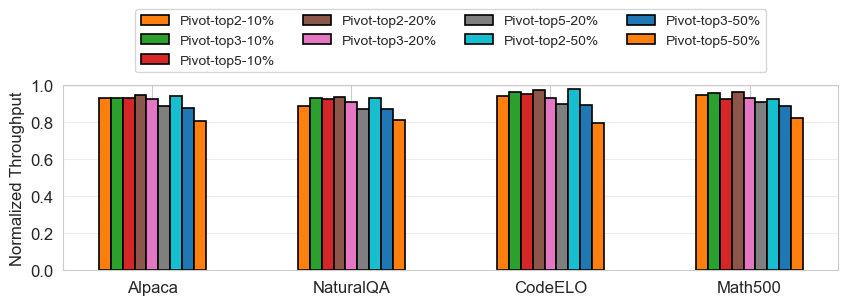

[skip] figure_1_sd_normalized_throughput_with_pivot_only: no Pivot top1 rows for Qwen3-32B with expansion_pct=0.1
[skip] figure_1_sd_normalized_throughput_with_pivot_only: no Pivot top1 rows for Qwen3-32B with expansion_pct=0.2
[skip] figure_1_sd_normalized_throughput_with_pivot_only: no Pivot top1 rows for Qwen3-32B with expansion_pct=0.5

[figure_1_sd_normalized_throughput_with_pivot_only] target_model=Qwen3-32B
policy=dynamic, expansion_pcts=[0.1, 0.2, 0.5], k=5, temp=None

method=Pivot-top2-10%
  dataset=Alpaca     pivot_throughput=1221.781998 sd_throughput=1270.239760 normalized_to_sd=0.961851 vs_sd_increase=-0.038149 vs_sd_percent=-3.81%
  dataset=NaturalQA  pivot_throughput=1117.224941 sd_throughput=1177.169483 normalized_to_sd=0.949077 vs_sd_increase=-0.050923 vs_sd_percent=-5.09%
  dataset=CodeELO    pivot_throughput=1146.443282 sd_throughput=1131.255398 normalized_to_sd=1.013426 vs_sd_increase=0.013426 vs_sd_percent=1.34%
  dataset=Math500    pivot_throughput=1614.066027 sd_t

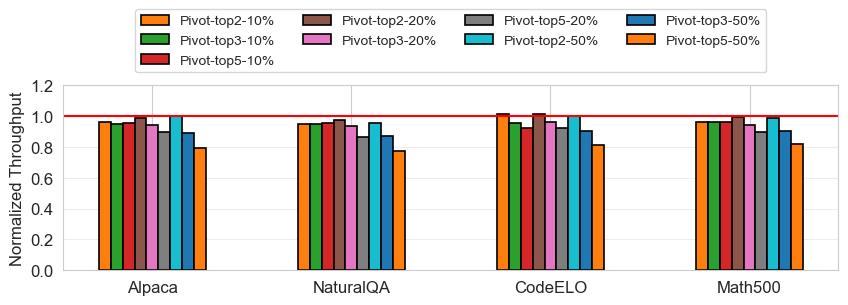

In [204]:
# =========================
# SD-normalized throughput
# Plot only Pivot bars
# Pivot-top{k}-{pct}% for pct in [10, 20, 50]
# =========================

SD_NORM_PIVOT_TOPKS = [1, 2, 3, 5]
SD_NORM_EXPANSION_PCTS = [0.1, 0.2, 0.5]
SD_NORM_PIVOT_POLICY = "dynamic"
SD_NORM_TEMP = None   # 0.0, 0.3, 0.7 등으로 설정 가능

SD_NORM_METHODS = [
    f"Pivot-top{k}-{int(pct * 100)}%"
    for pct in SD_NORM_EXPANSION_PCTS
    for k in SD_NORM_PIVOT_TOPKS
]

SD_NORM_METHOD_COLORS = color_map(SD_NORM_METHODS)


def _normalize_expansion_pct(series):
    vals = pd.to_numeric(series, errors="coerce")
    vals = vals.where(vals <= 1.0, vals / 100.0)
    return vals


def _filter_temp_optional_sd_norm(df, temp=SD_NORM_TEMP):
    if temp is None:
        return df.copy()

    if "temperature" not in df.columns:
        return df.copy()

    out = df.copy()
    temp_vals = pd.to_numeric(out["temperature"], errors="coerce")
    return out[np.isclose(temp_vals, float(temp))].copy()


def _geomean(values, eps=1e-12):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    if len(values) == 0:
        return np.nan

    values = np.clip(values, eps, None)
    return float(np.exp(np.mean(np.log(values))))


def _filter_sd_rows_for_sd_norm(df):
    out = df.copy()
    out = out[out["method_pretty"] == "SD"].copy()

    if "speculative_length" in out.columns:
        out = out[out["speculative_length"] == SPECULATIVE_LENGTH].copy()

    out = _filter_temp_optional_sd_norm(out)
    return out


def _filter_pivot_rows_for_sd_norm(df):
    out = df.copy()
    out = out[out["method_pretty"] == "Pivot"].copy()

    if "speculative_length" in out.columns:
        out = out[out["speculative_length"] == SPECULATIVE_LENGTH].copy()

    if "pivot_expansion_policy" in out.columns:
        policy = out["pivot_expansion_policy"].astype(str).str.lower()
        out = out[policy.str.contains(SD_NORM_PIVOT_POLICY, na=False)].copy()

    out = _filter_temp_optional_sd_norm(out)
    return out


def plot_figure_1_sd_normalized_throughput_with_pivot_only():
    fig_name = "figure_1_sd_normalized_throughput_with_pivot_only"

    required_cols = [
        "target_model",
        "dataset",
        "method_pretty",
        "throughput",
        "pivot_expansion_pct",
        "pivot_topk",
        "pivot_expansion_policy",
    ]

    if not nonempty(results_df, required_cols, fig_name):
        return

    df_all = results_df.copy()
    df_all = _filter_temp_optional_sd_norm(df_all)

    if df_all.empty:
        print(f"[skip] {fig_name}: no rows after temperature filtering")
        return

    target_models_local = sorted(
        df_all["target_model"]
        .dropna()
        .astype(str)
        .unique()
    )

    for target_model in target_models_local:
        df = df_all[df_all["target_model"].astype(str) == str(target_model)].copy()

        if df.empty:
            print(f"[skip] {fig_name}: no rows for {target_model}")
            continue

        sd_df = _filter_sd_rows_for_sd_norm(df)
        pivot_df_all = _filter_pivot_rows_for_sd_norm(df)

        if sd_df.empty:
            print(f"[skip] {fig_name}: no SD rows for {target_model}")
            continue

        if pivot_df_all.empty:
            print(
                f"[skip] {fig_name}: no Pivot rows for {target_model} "
                f"with policy={SD_NORM_PIVOT_POLICY}"
            )
            continue

        sd_agg = (
            sd_df.dropna(subset=["throughput"])
            .groupby("dataset", as_index=False)["throughput"]
            .mean()
            .rename(columns={"throughput": "sd_throughput"})
        )

        rows = []

        for pct in SD_NORM_EXPANSION_PCTS:
            pct_vals = _normalize_expansion_pct(pivot_df_all["pivot_expansion_pct"])
            pivot_df_pct = pivot_df_all[np.isclose(pct_vals, pct, atol=1e-6)].copy()

            if pivot_df_pct.empty:
                print(
                    f"[skip] {fig_name}: no Pivot rows for {target_model} "
                    f"with expansion_pct={pct}"
                )
                continue

            for topk in SD_NORM_PIVOT_TOPKS:
                sub = pivot_df_pct[
                    pd.to_numeric(pivot_df_pct["pivot_topk"], errors="coerce").eq(topk)
                ].copy()

                if sub.empty:
                    print(
                        f"[skip] {fig_name}: no Pivot top{topk} rows for {target_model} "
                        f"with expansion_pct={pct}"
                    )
                    continue

                sub_agg = (
                    sub.dropna(subset=["throughput"])
                    .groupby("dataset", as_index=False)["throughput"]
                    .mean()
                    .rename(columns={"throughput": "pivot_throughput"})
                )

                merged = sub_agg.merge(sd_agg, on="dataset", how="inner")

                if merged.empty:
                    print(
                        f"[skip] {fig_name}: no merged rows for {target_model}, "
                        f"topk={topk}, pct={pct}"
                    )
                    continue

                method_label = f"Pivot-top{topk}-{int(pct * 100)}%"

                for _, row in merged.iterrows():
                    rows.append(
                        {
                            "dataset": row["dataset"],
                            "method_label": method_label,
                            "raw_throughput": float(row["pivot_throughput"]),
                            "sd_throughput": float(row["sd_throughput"]),
                            "normalized_throughput": (
                                float(row["pivot_throughput"])
                                / float(row["sd_throughput"])
                            ),
                        }
                    )

        plot_df = pd.DataFrame(rows)

        if plot_df.empty:
            print(f"[skip] {fig_name}: empty plot_df for {target_model}")
            continue

        datasets = [d for d in DATASET_ORDER if d in set(plot_df["dataset"])]
        datasets += [
            d for d in sorted_datasets(plot_df["dataset"].unique())
            if d not in datasets
        ]

        methods = [
            m for m in SD_NORM_METHODS
            if m in set(plot_df["method_label"])
        ]

        x = np.arange(len(datasets))
        width = 0.06

        fig, ax = plt.subplots(figsize=(10, 2.4))

        all_vals = []

        print("\n" + "=" * 100)
        print(f"[{fig_name}] target_model={target_model}")
        print(
            f"policy={SD_NORM_PIVOT_POLICY}, "
            f"expansion_pcts={SD_NORM_EXPANSION_PCTS}, "
            f"k={SPECULATIVE_LENGTH}, "
            f"temp={SD_NORM_TEMP}"
        )
        print("=" * 100)

        for i, method in enumerate(methods):
            vals = []
            raw_vals = []
            sd_vals = []

            for dataset in datasets:
                sub = plot_df[
                    (plot_df["dataset"] == dataset)
                    & (plot_df["method_label"] == method)
                ]

                if sub.empty:
                    vals.append(np.nan)
                    raw_vals.append(np.nan)
                    sd_vals.append(np.nan)
                else:
                    vals.append(float(sub["normalized_throughput"].iloc[0]))
                    raw_vals.append(float(sub["raw_throughput"].iloc[0]))
                    sd_vals.append(float(sub["sd_throughput"].iloc[0]))

            all_vals.extend([v for v in vals if np.isfinite(v)])

            print(f"\nmethod={method}")

            for dataset, y, raw_y, sd_y in zip(datasets, vals, raw_vals, sd_vals):
                increase = y - 1.0 if np.isfinite(y) else np.nan
                percent = increase * 100.0 if np.isfinite(increase) else np.nan

                print(
                    f"  dataset={dataset:<10} "
                    f"pivot_throughput={raw_y:.6f} "
                    f"sd_throughput={sd_y:.6f} "
                    f"normalized_to_sd={y:.6f} "
                    f"vs_sd_increase={increase:.6f} "
                    f"vs_sd_percent={percent:.2f}%"
                )

            gmean_norm = _geomean(vals)
            gmean_increase = gmean_norm - 1.0
            gmean_percent = gmean_increase * 100.0

            print(f"  geomean_normalized_to_sd={gmean_norm:.6f}")
            print(
                f"  geomean_vs_sd_increase={gmean_increase:.6f} "
                f"geomean_vs_sd_percent={gmean_percent:.2f}%"
            )

            offset = (i - (len(methods) - 1) / 2) * width

            ax.bar(
                x + offset,
                vals,
                width=width,
                label=method,
                color=SD_NORM_METHOD_COLORS[method],
                edgecolor="black",
                linewidth=1.2,
            )

        ymax = (
            1.0
            if len(all_vals) == 0
            else max(1.0, np.ceil(max(all_vals) / 0.2) * 0.2)
        )
        ymax = min(ymax, 2.0)

        ax.set_xticks(x)
        ax.set_xticklabels(datasets)
        ax.set_ylabel("Normalized Throughput")
        ax.set_ylim(0.0, ymax)
        ax.set_yticks(np.arange(0.0, ymax + 1e-9, 0.2))
        ax.grid(True, axis="y", alpha=0.35)

        ax.axhline(
            y=1.0,
            color="red",
            linestyle="-",
            linewidth=1.5,
        )

        ax.legend(
            loc="upper center",
            bbox_to_anchor=(0.5, 1.45),
            ncol=4,
            fancybox=True,
            shadow=False,
            fontsize=10,
            frameon=True,
        )

        temp_suffix = (
            ""
            if SD_NORM_TEMP is None
            else f"_temp{safe_temp_label(SD_NORM_TEMP)}"
        )
        policy_suffix = f"_{SD_NORM_PIVOT_POLICY}"
        pct_suffix = "_multi_pct"

        save_fig(
            fig,
            get_target_out_dir(target_model),
            f"{fig_name}{policy_suffix}{temp_suffix}{pct_suffix}_k{SPECULATIVE_LENGTH}",
        )

        plt.show()


plot_figure_1_sd_normalized_throughput_with_pivot_only()